<a href="https://colab.research.google.com/github/leeobazzana01/Mobile-Market-Share-/blob/main/mobile_market_share_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile Market Share 2026

## Engenharia de Aplicações Móveis - Docente: Will Machado

---

## Introdução

O presente dataset, elaborado pelos alunos **Leonardo José Bazana Lima, Pedro Paulo Fontelles Tooda e Vinicius Henrique Muniz**, propõe **responder questões relacionadas ao desenvolvimento mobile de software** no Mercado de 2026, apontando as principais tendências considerando o impacto na adoção Grandes Modelos de Linguagem (LLMs) e ferramentas de Inteligência Artificial para a **Engenharia de Aplicações Móveis**.  

---


### 1) Pesquise em 2 fontes confiáveis (stackoverflow, Gartner, Microsoft, IBM, ...) **quais linguagens**(plataformas) de programação mobile tem sido mais usada pelo mercado nos anos de 2025, 2024 e 2023, no Brasil, nos EUA, na Europa e na Ásia. Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



Consideramos como fonte o **stackoverflow developer survey** nos anos de 2023, 2024 e 2025 para uma **Análise Exploratória de Dados Robusta**, apontando tendências globais no mercado de desenvolvimento mobile.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from google.colab import userdata
from pathlib import Path
import seaborn as sns
import warnings
import logging
import country_converter as coco

In [39]:


#baixando datasets
!kaggle datasets download -d stackoverflow/stack-overflow-2023-developers-survey #2023 survey
!kaggle datasets download -d ijnskjet/2024-stack-overflow-annual-developer-survey #2024
!kaggle datasets download -d edoardogalli/stack-overflow-annual-developer-survey-2025 #2025



Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stack-overflow-2023-developers-survey
License(s): unknown
100% 20.5M/20.5M [00:00<00:00, 107MB/s] 

Dataset URL: https://www.kaggle.com/datasets/ijnskjet/2024-stack-overflow-annual-developer-survey
License(s): EU ODP Legal Notice
100% 16.9M/16.9M [00:00<00:00, 107MB/s] 

Dataset URL: https://www.kaggle.com/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025
License(s): ODbL-1.0
100% 16.9M/16.9M [00:00<00:00, 79.4MB/s]



In [40]:
#criando uma lista de arquivos a serem extraídos
arquivos_kaggle_survey = [
  '2024-stack-overflow-annual-developer-survey.zip',
  'stack-overflow-2023-developers-survey.zip',
  'stack-overflow-annual-developer-survey-2025.zip']

#extraindo os arquivos .zip para uma pasta específica
pasta_destino_raiz = '/content/datasets_extraidos'

for arquivo in arquivos_kaggle_survey:

    nome_pasta = Path(arquivo).stem

    #criando o caminho final
    caminho_final_extracao = os.path.join(pasta_destino_raiz, nome_pasta)

    #criando a pasta caso nao existir
    os.makedirs(caminho_final_extracao, exist_ok=True)

    print(f"Extraindo {arquivo} para {caminho_final_extracao}...")

    with zipfile.ZipFile(arquivo, 'r') as zip_ref:
        #caminho da pasta específica criada como argumento
        zip_ref.extractall(caminho_final_extracao)

    print(f"Extração concluída. Removendo arquivo original...")

    os.remove(arquivo)
    print(f"Arquivo removido: {arquivo}\n")

print("Sucesso: datasets organizados, extraídos e dados compactados removidos!")

Extraindo 2024-stack-overflow-annual-developer-survey.zip para /content/datasets_extraidos/2024-stack-overflow-annual-developer-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: 2024-stack-overflow-annual-developer-survey.zip

Extraindo stack-overflow-2023-developers-survey.zip para /content/datasets_extraidos/stack-overflow-2023-developers-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-2023-developers-survey.zip

Extraindo stack-overflow-annual-developer-survey-2025.zip para /content/datasets_extraidos/stack-overflow-annual-developer-survey-2025...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-annual-developer-survey-2025.zip

Sucesso: datasets organizados, extraídos e dados compactados removidos!


In [41]:
#ocultando avisos do Python (Pandas/Seaborn)
warnings.filterwarnings('ignore')

#ocultando avisos do country_converter
logging.getLogger('country_converter').setLevel(logging.ERROR)

In [42]:
#lendo dados e criando dataframes
df_survey_2023 = pd.read_csv('/content/datasets_extraidos/stack-overflow-2023-developers-survey/survey_results_public.csv')
df_survey_2024 = pd.read_csv('/content/datasets_extraidos/2024-stack-overflow-annual-developer-survey/survey_results_public.csv')
df_survey_2025 = pd.read_csv('/content/datasets_extraidos/stack-overflow-annual-developer-survey-2025/survey_results_public.csv')

#criando copias

df_2023 = df_survey_2023.copy()
df_2024 = df_survey_2024.copy()
df_2025 = df_survey_2025.copy()

In [43]:
#criando um novo dataframe de 2023 apenas com as características relevantes
colunas_desejadas_2023 = ['Employment', 'YearsCode', 'DevType', 'OrgSize', 'Country', 'ProfessionalTech', 'Industry', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'ToolsTechHaveWorkedWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackSyncHaveWorkedWith', 'AIToolCurrently Using']

df_23 = df_2023[colunas_desejadas_2023]

df_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Employed, full-time",18,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",HTML/CSS;JavaScript;Python,Supabase,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Asana;Basecamp;GitHub Discussions;Jira;Linear;...,Cisco Webex Teams;Discord;Google Chat;Google M...,Writing code;Committing and reviewing code
2,"Employed, full-time",27,"Developer, back-end","5,000 to 9,999 employees",United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Bash/Shell (all shells);Go,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,Cargo;Docker;Kubernetes;Make;Nix,Markdown File;Stack Overflow for Teams,Microsoft Teams;Slack;Zoom,NaN
3,"Employed, full-time",12,"Developer, front-end",100 to 499 employees,United States of America,Automated testing;Continuous integration (CI) ...,NaN,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,PostgreSQL;Redis,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Homebrew;npm;Vite;Webpack;Yarn,Jira,Discord;Google Meet;Microsoft Teams;Slack;Zoom,NaN
4,"Employed, full-time;Independent contractor, fr...",6,"Developer, full-stack",20 to 99 employees,Philippines,Microservices;Automated testing;Observability ...,Other,HTML/CSS;JavaScript;TypeScript,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Docker;npm;Webpack;Yarn,Confluence;Jira;Notion,Discord;Google Meet;Slack;Zoom,Learning about a codebase;Writing code;Documen...


In [44]:
#analisando todas as categorias presentes no dataset
contagem_devtype_23 = df_23['DevType'].value_counts()

print(contagem_devtype_23)


DevType
Developer, full-stack                            25735
Developer, back-end                              13745
Developer, front-end                              5071
Developer, desktop or enterprise applications     3904
Other (please specify):                           3080
Developer, mobile                                 2597
Engineering manager                               2033
Student                                           1996
Developer, embedded applications or devices       1845
Data scientist or machine learning specialist     1588
DevOps specialist                                 1387
Academic researcher                               1354
Research & Development role                       1353
Senior Executive (C-Suite, VP, etc.)              1332
Engineer, data                                    1248
Cloud infrastructure engineer                     1036
Developer, game or graphics                        866
Data or business analyst                           837
Sy

In [45]:
#filtrando apenas os desenvolvedores mobile
df_mobile_23 = df_23[df_23['DevType'].str.contains('Developer, mobile', na=False)].copy()

df_mobile_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
51,"Employed, full-time",4,"Developer, mobile",20 to 99 employees,Sri Lanka,Automated testing,Other,Swift,Firebase Realtime Database,NaN,NaN,NaN,NaN,Google Chat;Google Meet,Documenting code
54,"Employed, full-time",5,"Developer, mobile",I don’t know,Lebanon,NaN,NaN,Java;JavaScript;Kotlin;SQL;TypeScript,Firebase Realtime Database;Microsoft SQL Serve...,NaN,Node.js;React;Spring Boot,Dagger;Gradle;Maven (build tool),Confluence,Google Meet;Microsoft Teams;Slack;Zoom,NaN
176,"Employed, full-time",6,"Developer, mobile","Just me - I am a freelancer, sole proprietor, ...","Iran, Islamic Republic of...",DevOps function,Other,C;C++;Dart;Java;SQL,Microsoft SQL Server;MongoDB;MySQL;SQLite,Firebase;Google Cloud;VMware,NaN,CMake;Gradle,GitHub Discussions;Jira;Stack Overflow for Tea...,Discord;Google Meet;Skype;Slack;Telegram;Whatsapp,Project planning;Writing code;Debugging and ge...
177,"Employed, full-time",10,"Developer, mobile",20 to 99 employees,India,NaN,"Information Services, IT, Software Development...",Objective-C,SQLite,NaN,NaN,NaN,NaN,Microsoft Teams;Skype,NaN
179,"Employed, full-time;Student, full-time",5,"Developer, mobile",NaN,Lebanon,None of these,NaN,MATLAB;Swift,PostgreSQL,Digital Ocean;Google Cloud;Heroku;Microsoft Az...,NaN,Docker;Homebrew;LLVM's Clang,NaN,Google Meet;Microsoft Teams;Whatsapp;Zoom,NaN


In [46]:
#configurações globais de estilo visual EDA
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [47]:
def preparar_df_mobile(df: pd.DataFrame, ano: int) -> pd.DataFrame:
    #filtrando apenas os desenvolvedores mobile em cada dataset"
    df_copy = df.copy()

    #filtro de devs mobile
    if 'DevType' in df_copy.columns:
        mascara = df_copy['DevType'].astype(str).str.contains('mobile', case=False, na=False)
        df_copy = df_copy[mascara].copy()

    #mapeando os países e continentes
    if 'Country' in df_copy.columns and 'Continent' not in df_copy.columns:
        paises = df_copy['Country'].dropna().tolist()
        df_copy['Continent'] = 'Unknown'
        df_copy.loc[df_copy['Country'].notna(), 'Continent'] = coco.convert(
            names=paises, to='continent'
        )

    print(f"Dataset Mobile {ano} preparado. Total de registros: {len(df_copy)}")
    return df_copy

In [48]:
def plotar_distribuicao_continentes(df_mobile: pd.DataFrame, ano: int):
    #plotando a distribuuiçao total de desenvolvedores por continente
    distribuicao = df_mobile['Continent'].value_counts()

    plt.figure(figsize=(9, 5))
    distribuicao.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(f'Stack Overflow Survey {ano} - Devs Mobile por Continente', fontsize=13, weight='bold')
    plt.xlabel('Continente', fontsize=11)
    plt.ylabel('Número de Desenvolvedores', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [49]:
def plotar_categoria_por_continente(
    df_mobile: pd.DataFrame,
    coluna: str,
    rotulo_eixo: str,
    titulo_categoria: str,
    ano: int,
    continentes: list = ['Europe', 'Asia', 'America'],
    top_n: int = 5
):
    """
    Função genérica que desmembra respostas multivaloradas, filtra continentes
    e plota o FacetGrid ordenado com o Top N por continente.
    """
    if coluna not in df_mobile.columns:
        print(f" Coluna '{coluna}' não encontrada para o ano {ano}.")
        return

    # Filtra continentes selecionados
    df_filtrado = df_mobile[df_mobile['Continent'].isin(continentes)].copy()

    # Desmembra valores separados por ';'
    df_explodido = (
        df_filtrado.assign(Item=df_filtrado[coluna].str.split(';'))
        .explode('Item')
        .dropna(subset=['Item'])
    )
    df_explodido['Item'] = df_explodido['Item'].str.strip()

    # Contagem e ordenação por continente
    tabela_freq = (
        df_explodido.groupby(['Continent', 'Item'])
        .size()
        .reset_index(name='Count')
    )

    top_por_continente = (
        tabela_freq.groupby('Continent', group_keys=False)
        .apply(lambda x: x.nlargest(top_n, 'Count'))
        .reset_index(drop=True)
    )

    # Plotagem via FacetGrid
    g = sns.FacetGrid(
        top_por_continente,
        col='Continent',
        sharey=False,
        height=4.5,
        aspect=1.2
    )
    g.map_dataframe(
        sns.barplot,
        x='Count',
        y='Item',
        palette='viridis',
        edgecolor='black'
    )

    g.set_axis_labels('Número de Desenvolvedores', rotulo_eixo)
    g.set_titles(col_template='Continente: {col_name}')
    g.fig.subplots_adjust(top=0.8)
    g.fig.suptitle(
        f'Stack Overflow Developer Survey {ano}\nTop {titulo_categoria} Mobile por Continente',
        fontsize=14,
        weight='bold'
    )
    plt.tight_layout()
    plt.show()

In [50]:
def plotar_top_pizza(df_mobile: pd.DataFrame, coluna: str, titulo: str, ano: int, top_n: int = 6):
    #gera um gráfico de pizza para o Top N global
    if coluna not in df_mobile.columns:
        print(f"Coluna '{coluna}' não encontrada para o ano {ano}.")
        return

    itens = df_mobile[coluna].dropna().str.split(';').explode().str.strip()
    top_itens = itens.value_counts().head(top_n)

    plt.figure(figsize=(7, 7))
    top_itens.plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        cmap='Set3',
        wedgeprops={'edgecolor': 'white'}
    )
    plt.title(f'Stack Overflow Survey {ano} - Top {top_n} {titulo}', fontsize=13, weight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()



In [51]:
#executando o pipleine completo

def executar_pipeline_completo(df_2023: pd.DataFrame, df_2024: pd.DataFrame, df_2025: pd.DataFrame):

    #dicionario com os dataframes a serem analisados
    raw_dfs = {2023: df_2023, 2024: df_2024, 2025: df_2025}

    mobile_dfs = {}

    #processa cada cada ano para o ecossistema Mobile
    for ano, df in raw_dfs.items():
        print(f"\n--- PROCESSANDO ANO {ano} ---")
        df_mob = preparar_df_mobile(df, ano)
        mobile_dfs[ano] = df_mob

        #visualizações por ano
        plotar_distribuicao_continentes(df_mob, ano)
        plotar_top_pizza(df_mob, 'LanguageHaveWorkedWith', 'Linguagens Mobile', ano)

        #analises por Continente
        plotar_categoria_por_continente(
            df_mob, 'LanguageHaveWorkedWith', 'Linguagem', 'Linguagens Mobile', ano
        )
        plotar_categoria_por_continente(
            df_mob, 'DatabaseHaveWorkedWith', 'Banco de Dados', 'Bancos de Dados Mobile', ano
        )
        plotar_categoria_por_continente(
            df_mob, 'PlatformHaveWorkedWith', 'Plataforma', 'Plataformas de Nuvem Mobile', ano
        )

        #coluna de Frameworks (muda em 2025/2024/2023)
        col_fw = 'WebframeHaveWorkedWith' if 'WebframeHaveWorkedWith' in df_mob.columns else 'MiscTechHaveWorkedWith'
        plotar_categoria_por_continente(
            df_mob, col_fw, 'Framework', 'Frameworks Mobile', ano
        )



--- PROCESSANDO ANO 2023 ---
Dataset Mobile 2023 preparado. Total de registros: 2597


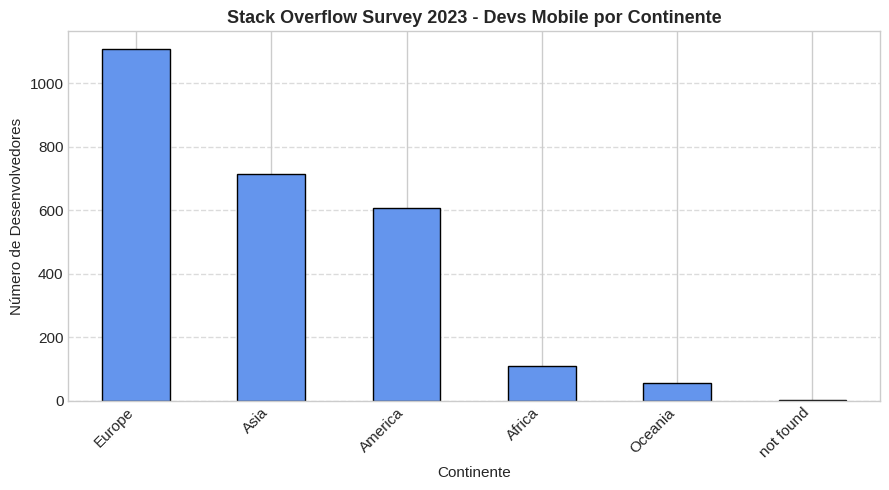

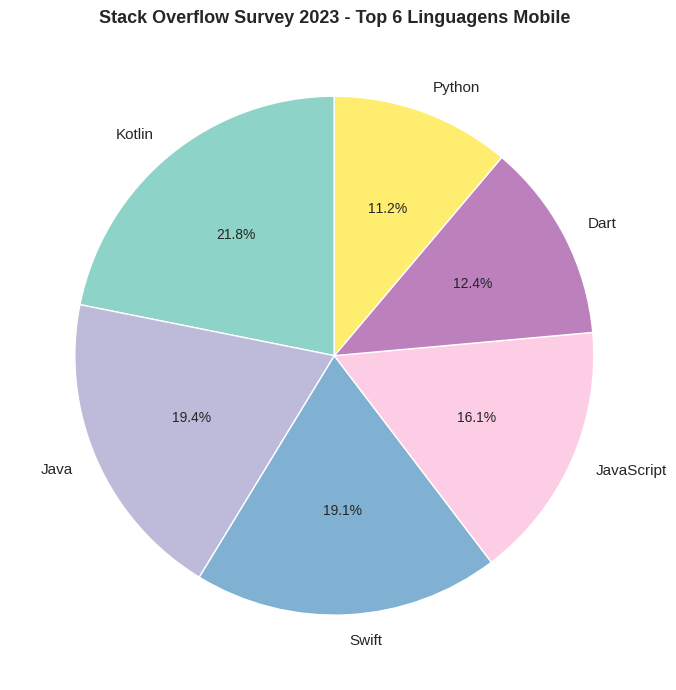

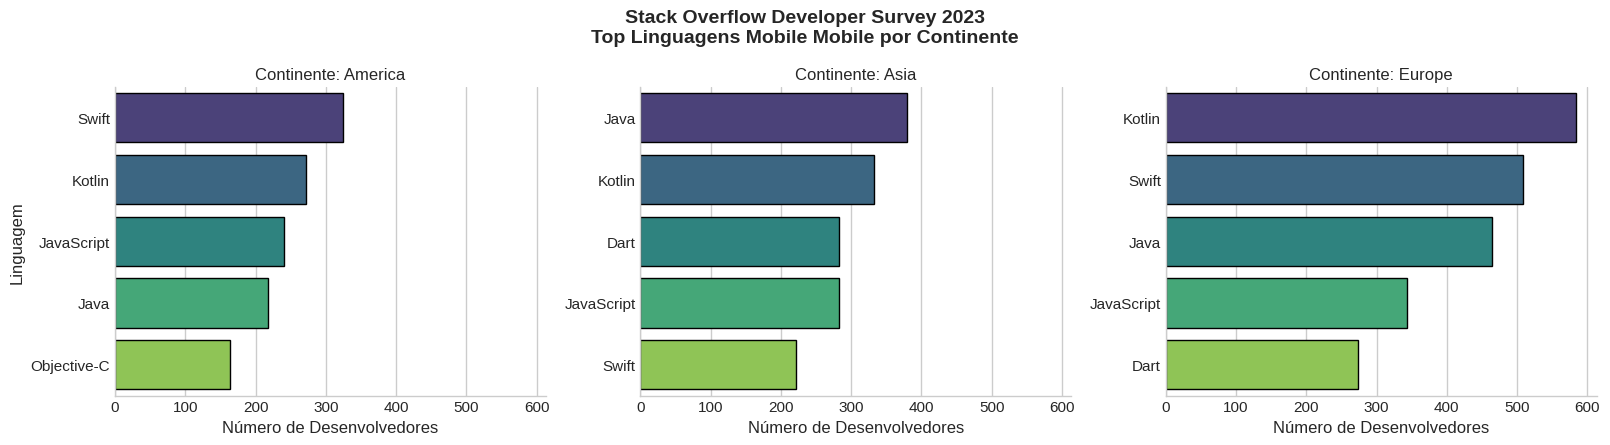

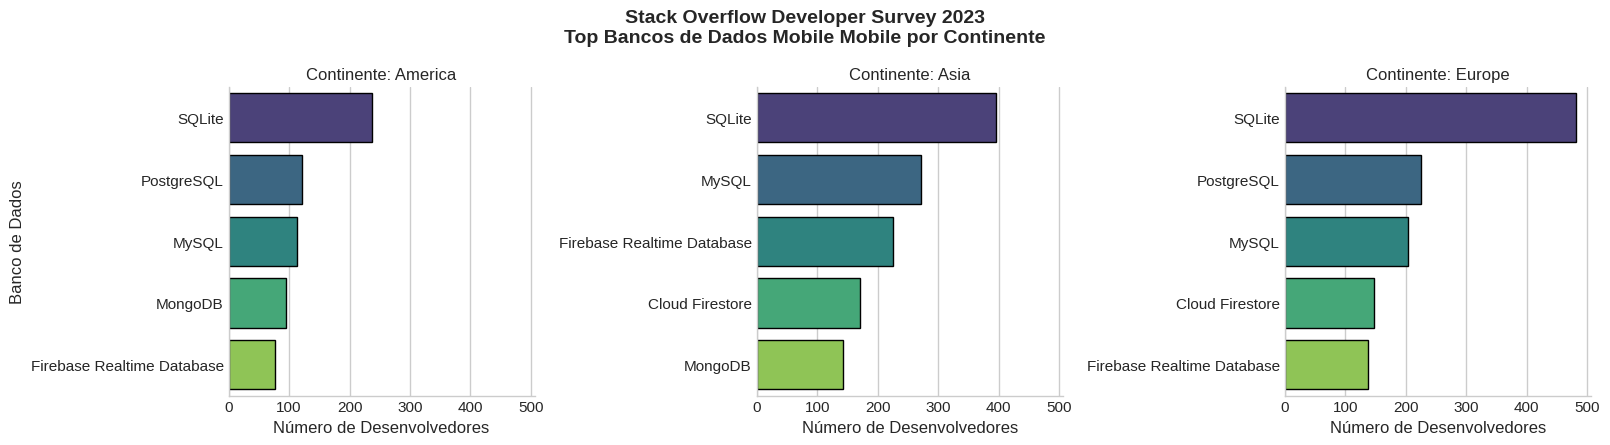

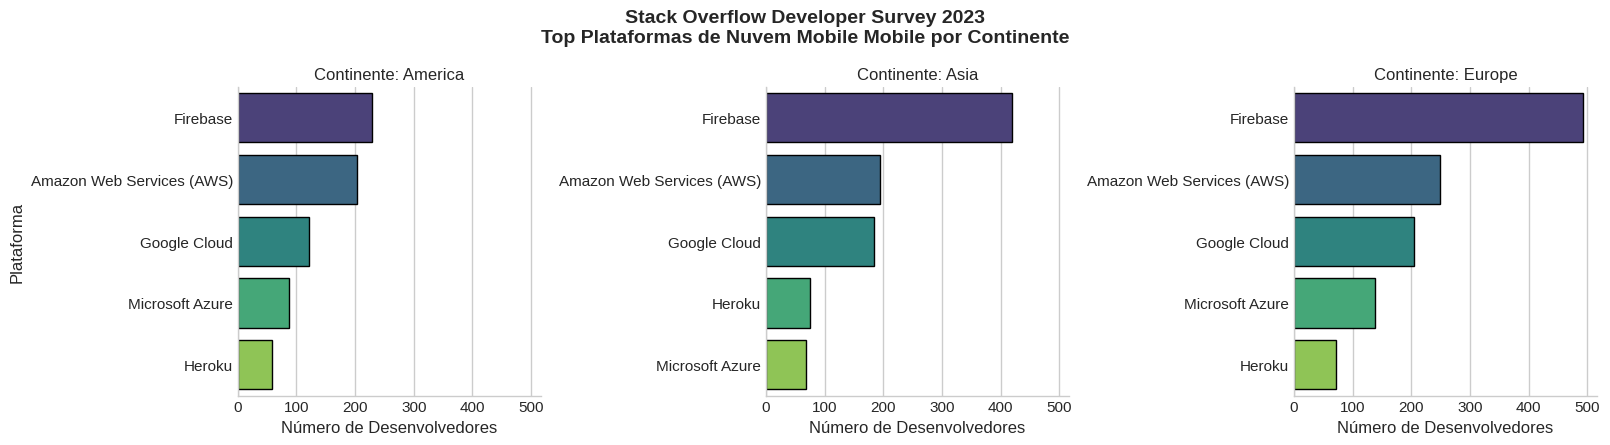

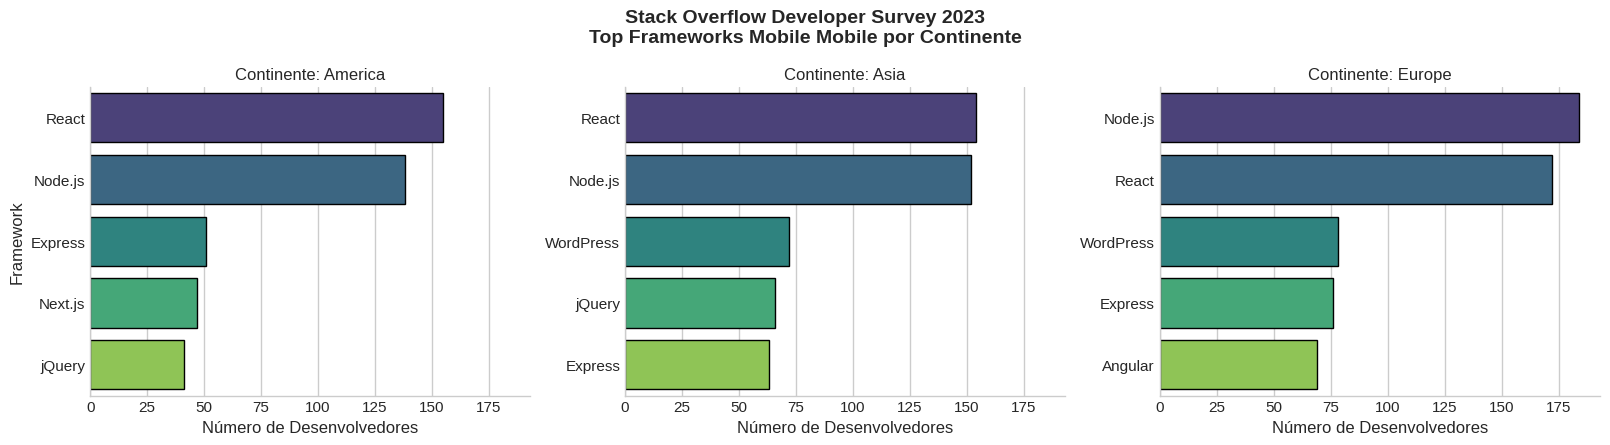


--- PROCESSANDO ANO 2024 ---
Dataset Mobile 2024 preparado. Total de registros: 2021


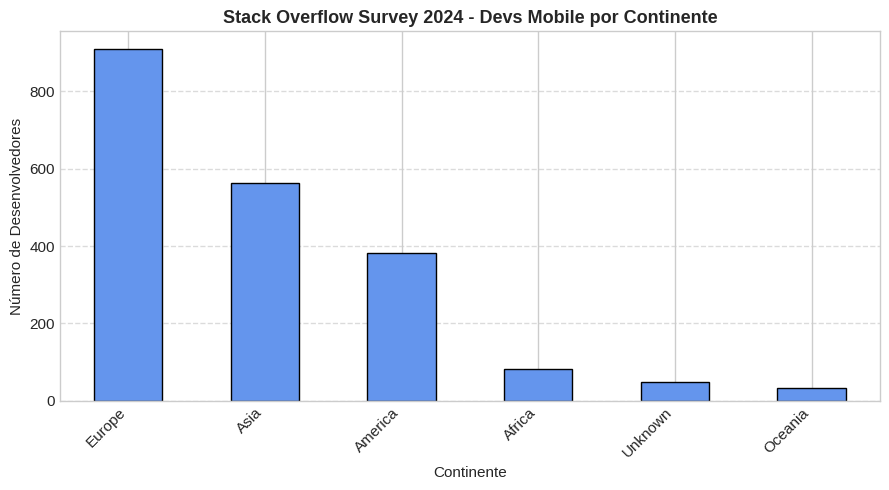

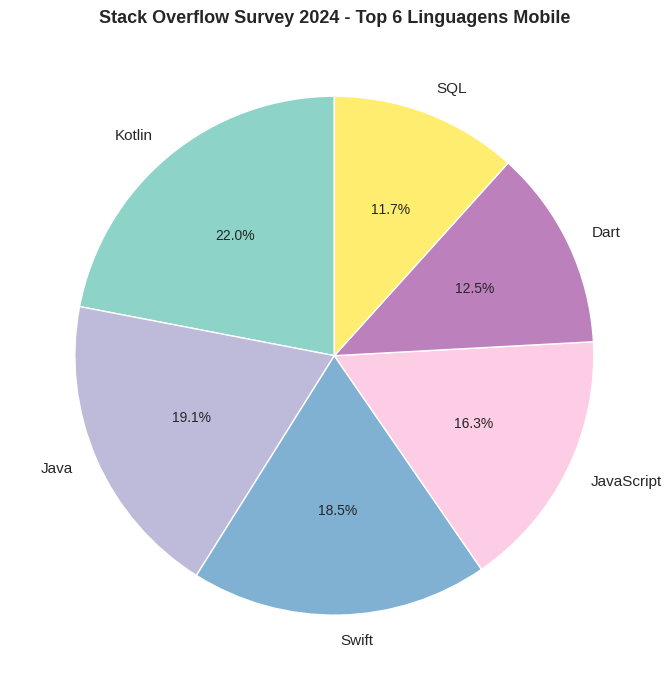

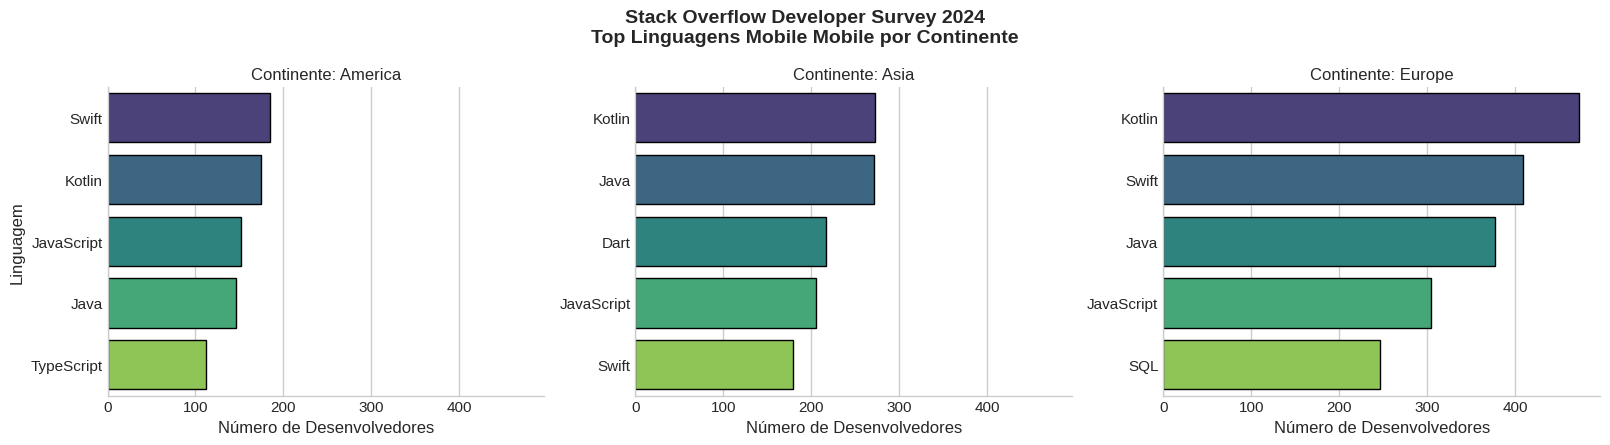

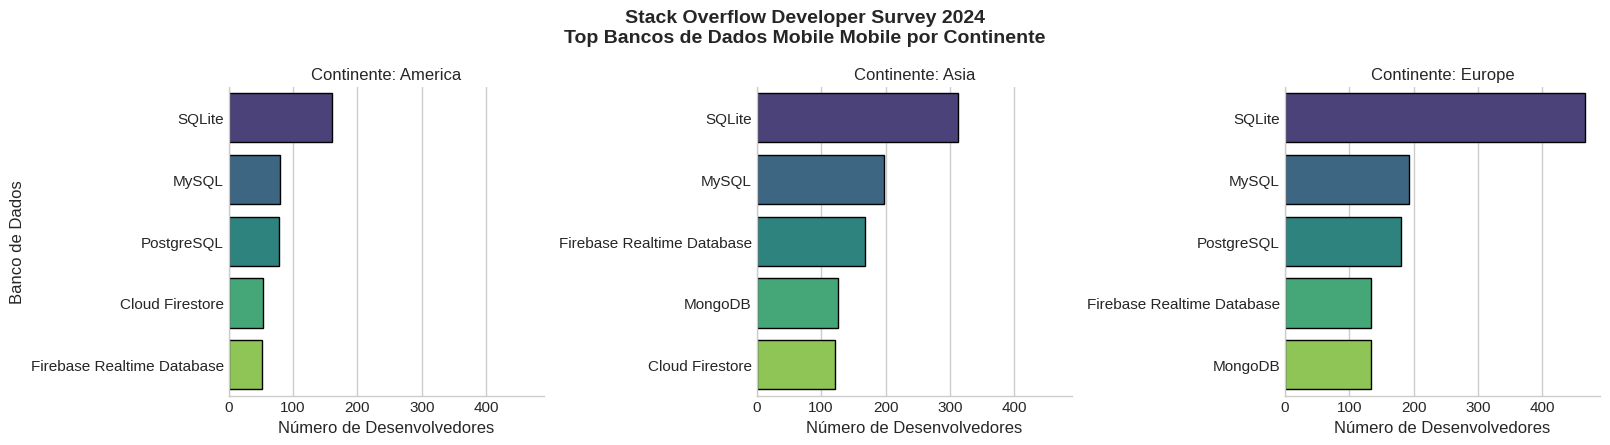

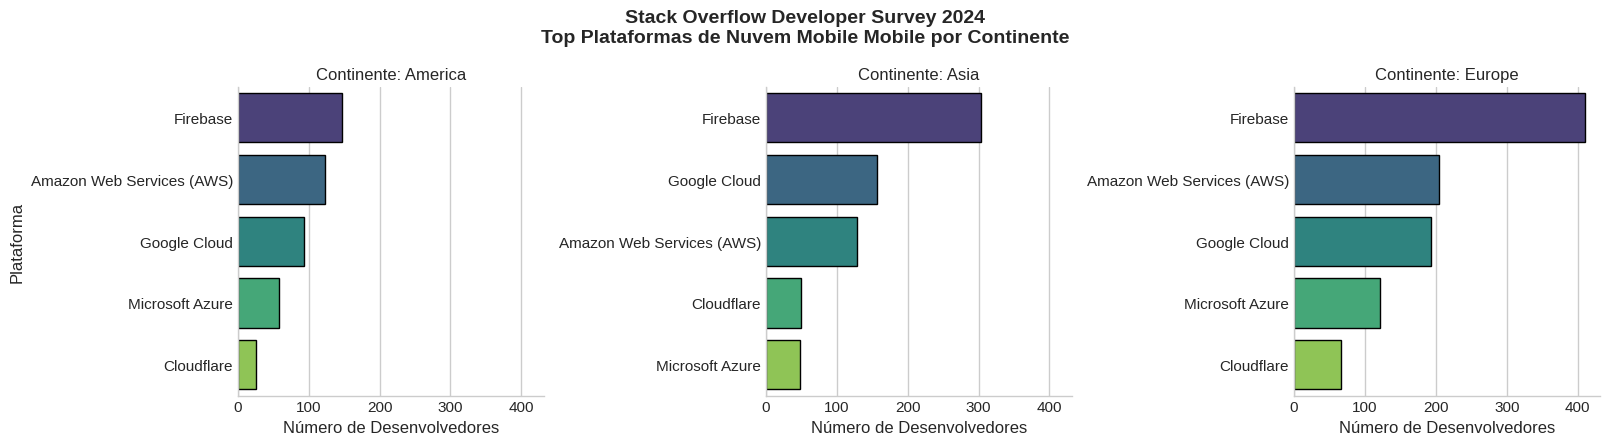

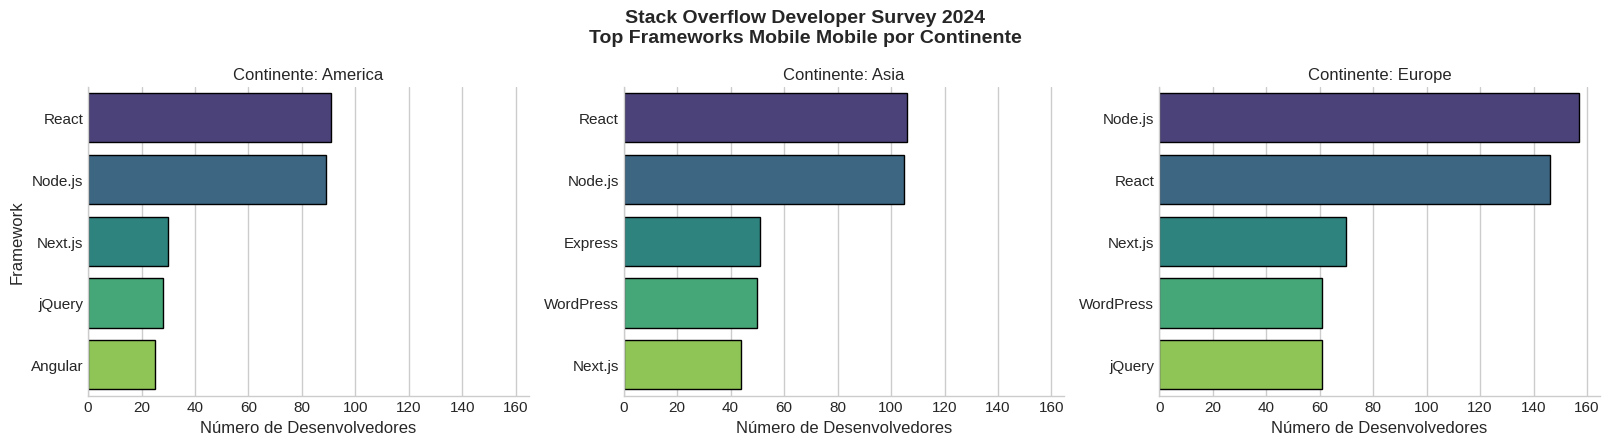


--- PROCESSANDO ANO 2025 ---
Dataset Mobile 2025 preparado. Total de registros: 1389


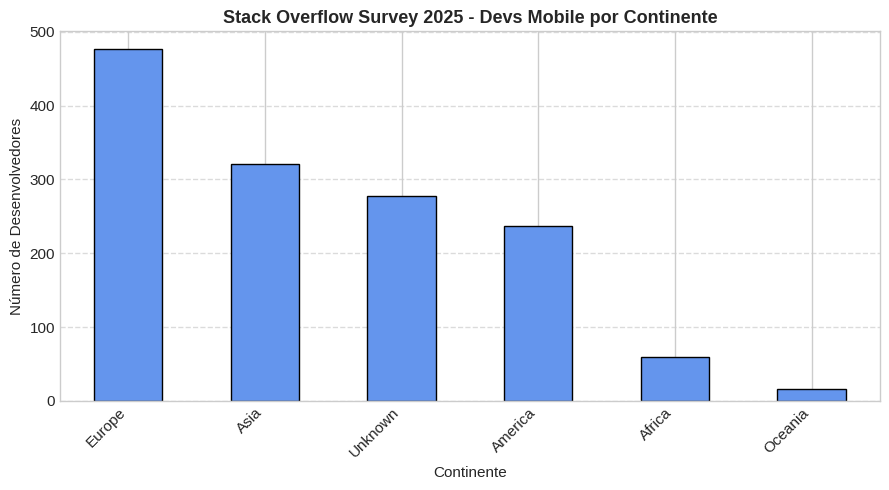

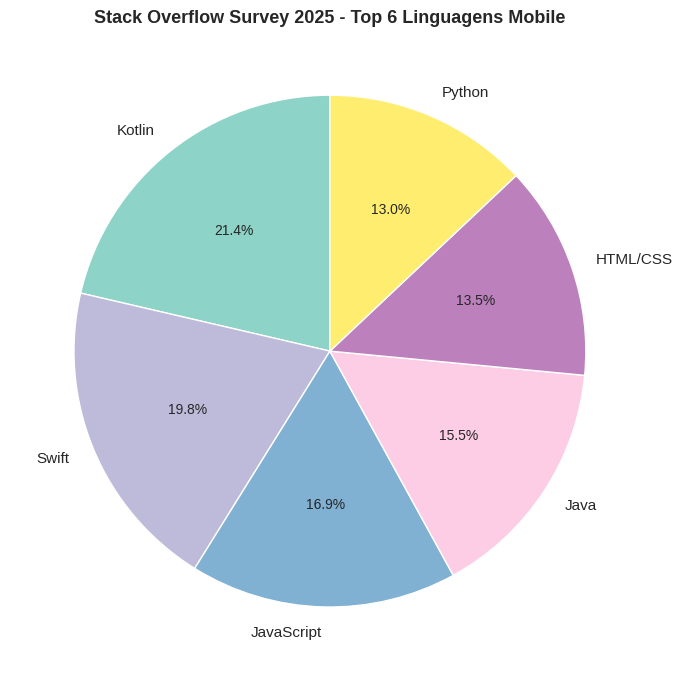

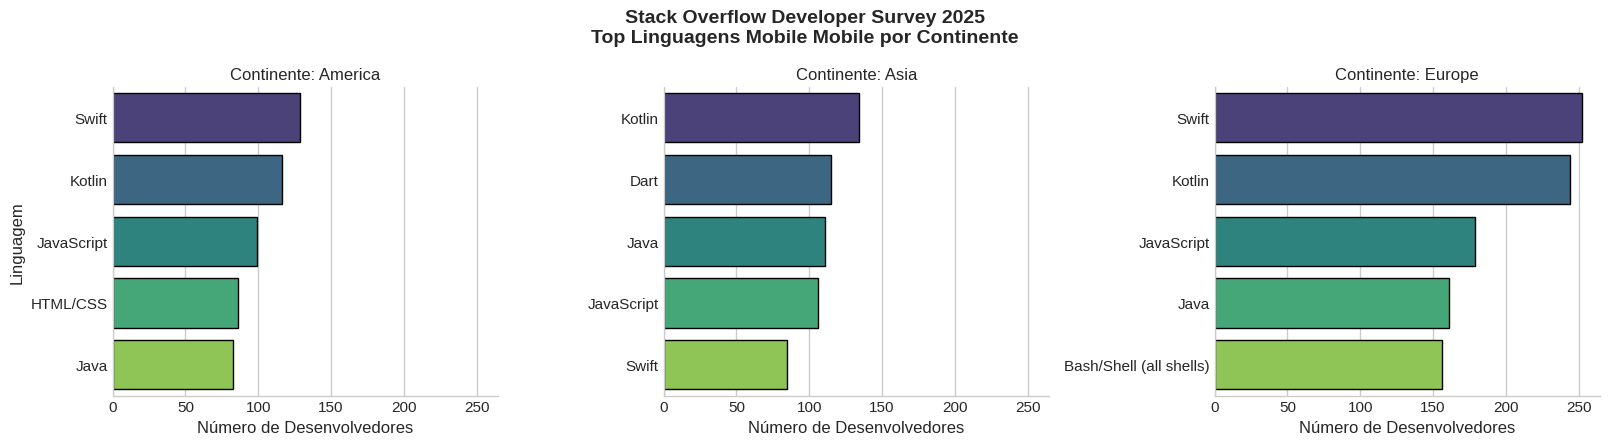

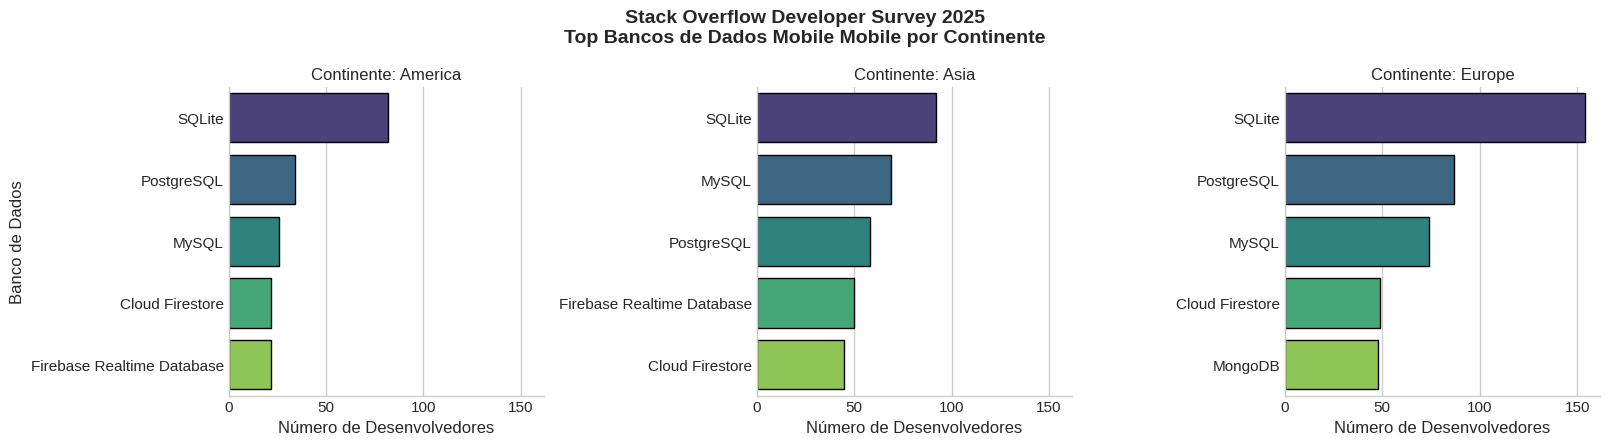

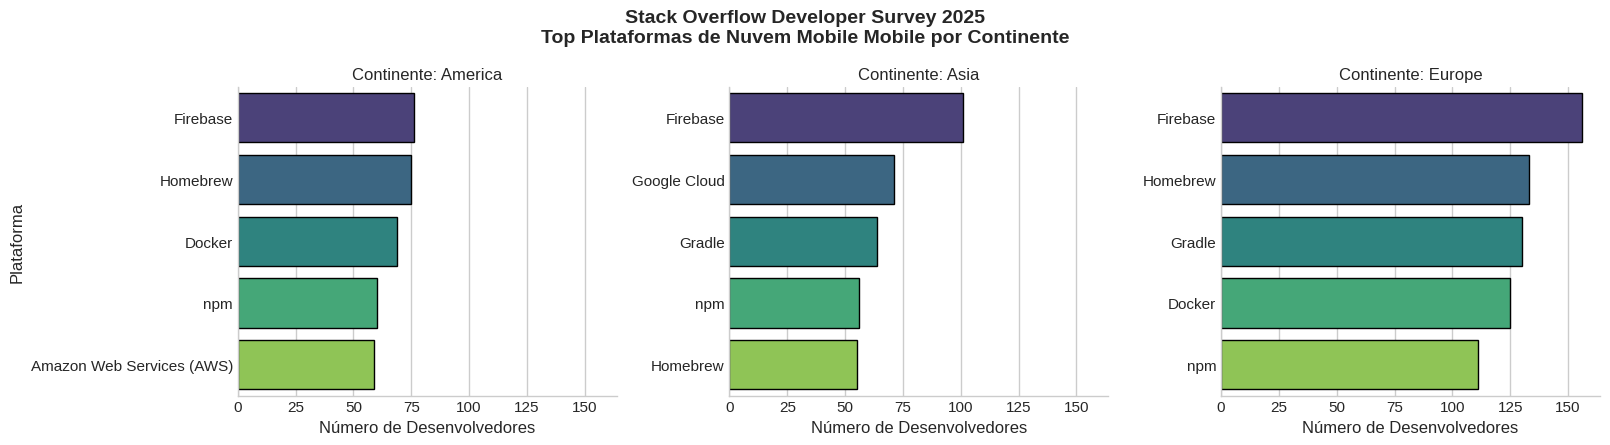

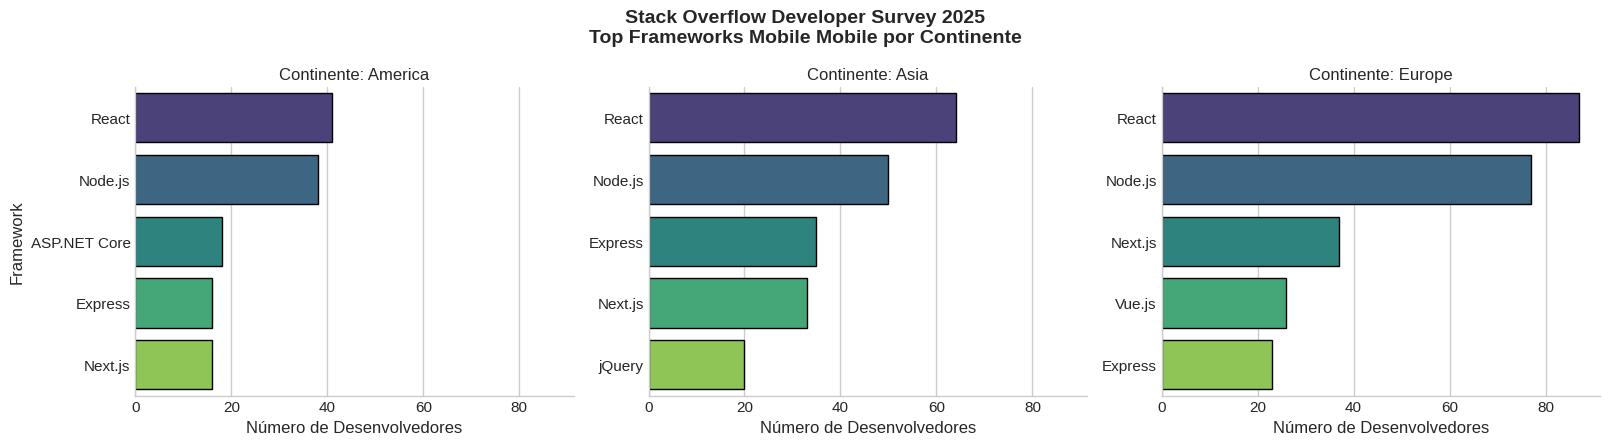

In [52]:
executar_pipeline_completo(df_2023, df_2024, df_2025)

## 2) Pesquise em 2 fontes confiáveis qual a participação de mercado (marketshare) dos dispositivos Android e iOS nos anos de 2025 e 2024, no Brasil, nos EUA, na Europa e na Ásia. Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



In [53]:
import requests
import pandas as pd
from io import StringIO

In [54]:
url = "https://counterpointresearch.com/en/insights/global-smartphone-os-market-share"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/131.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

response = requests.get(
    url,
    headers=headers,
    timeout=30
)

print(response.status_code)

html = response.text


200


In [55]:
#tentando extrair as tabelas
tabelas = pd.read_html(StringIO(html))

print(f"{len(tabelas)} tabelas encontradas")

for i, tabela in enumerate(tabelas):
    print(f"\n===== TABELA {i} =====")
    display(tabela)

4 tabelas encontradas

===== TABELA 0 =====


,Global,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,80%,74%,76%,79%,79%,72%,73%
1,iOS,16%,22%,19%,17%,17%,24%,22%
2,Harmony,4%,4%,5%,4%,4%,3%,5%



===== TABELA 1 =====


,US Share,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,48%,35%,45%,50%,45%,31%,41%
1,iOS,52%,65%,55%,50%,55%,69%,59%



===== TABELA 2 =====


,China Share,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,69%,64%,67%,66%,69%,61%,63%
1,Harmony,17%,19%,19%,17%,18%,16%,19%
2,iOS,14%,17%,14%,16%,14%,22%,17%



===== TABELA 3 =====


,India Share,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,95%,89%,92%,94%,92%,90%,90%
1,iOS,5%,11%,8%,6%,8%,10%,10%


In [56]:
nomes = {
    0: "Global",
    1: "EUA",
    2: "China",
    3: "Índia"
}

dados = {}

for i, nome in nomes.items():

    df = tabelas[i].copy()

    #1meira coluna contém Android/iOS/Harmony
    df = df.rename(columns={df.columns[0]: "Sistema"})

    #remove espaços
    df["Sistema"] = df["Sistema"].astype(str).str.strip()

    #mantem apenas Android e iOS
    df = df[
        df["Sistema"].isin(["Android", "iOS"])
    ].copy()

    #converte percentuais para números
    for coluna in df.columns[1:]:
        df[coluna] = (
            df[coluna]
            .astype(str)
            .str.replace("%", "", regex=False)
            .astype(float)
        )

    dados[nome] = df



In [57]:
#mostrando resultados organizados
for nome, df in dados.items():

    print("\n" + "=" * 60)
    print(nome)
    print("=" * 60)

    display(df)


Global


,Sistema,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,80.0,74.0,76.0,79.0,79.0,72.0,73.0
1,iOS,16.0,22.0,19.0,17.0,17.0,24.0,22.0



EUA


,Sistema,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,48.0,35.0,45.0,50.0,45.0,31.0,41.0
1,iOS,52.0,65.0,55.0,50.0,55.0,69.0,59.0



China


,Sistema,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,69.0,64.0,67.0,66.0,69.0,61.0,63.0
2,iOS,14.0,17.0,14.0,16.0,14.0,22.0,17.0



Índia


,Sistema,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026
0,Android,95.0,89.0,92.0,94.0,92.0,90.0,90.0
1,iOS,5.0,11.0,8.0,6.0,8.0,10.0,10.0


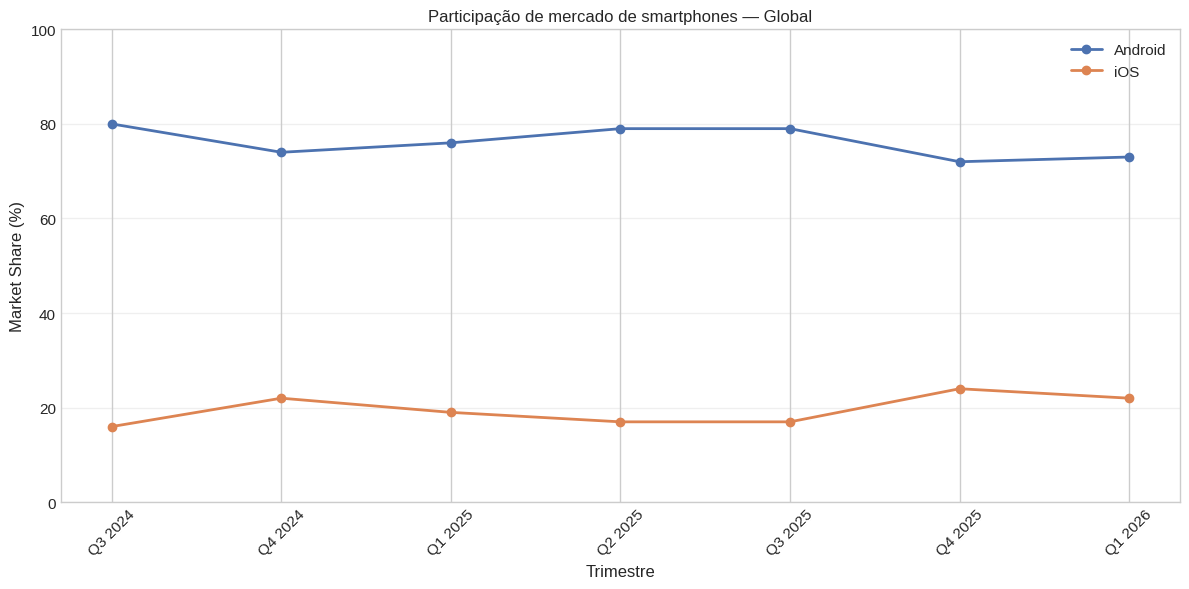

In [58]:
#grafico de marketshare global
df = dados["Global"]

df_plot = df.set_index("Sistema").T

plt.figure(figsize=(12, 6))

for sistema in ["Android", "iOS"]:

    plt.plot(
        df_plot.index,
        df_plot[sistema],
        marker="o",
        linewidth=2,
        label=sistema
    )

plt.title(
    "Participação de mercado de smartphones — Global"
)

plt.xlabel("Trimestre")
plt.ylabel("Market Share (%)")

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

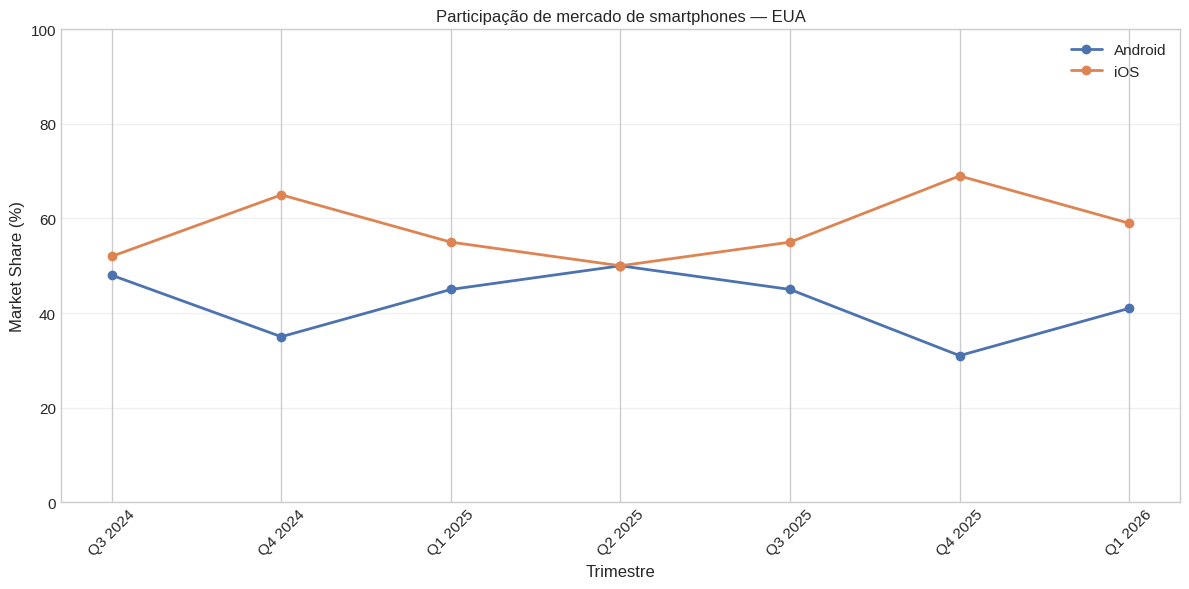

In [59]:
#grafico de marketshare norte americano
df = dados["EUA"]

df_plot = df.set_index("Sistema").T

plt.figure(figsize=(12, 6))

for sistema in ["Android", "iOS"]:

    plt.plot(
        df_plot.index,
        df_plot[sistema],
        marker="o",
        linewidth=2,
        label=sistema
    )

plt.title(
    "Participação de mercado de smartphones — EUA"
)

plt.xlabel("Trimestre")
plt.ylabel("Market Share (%)")

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

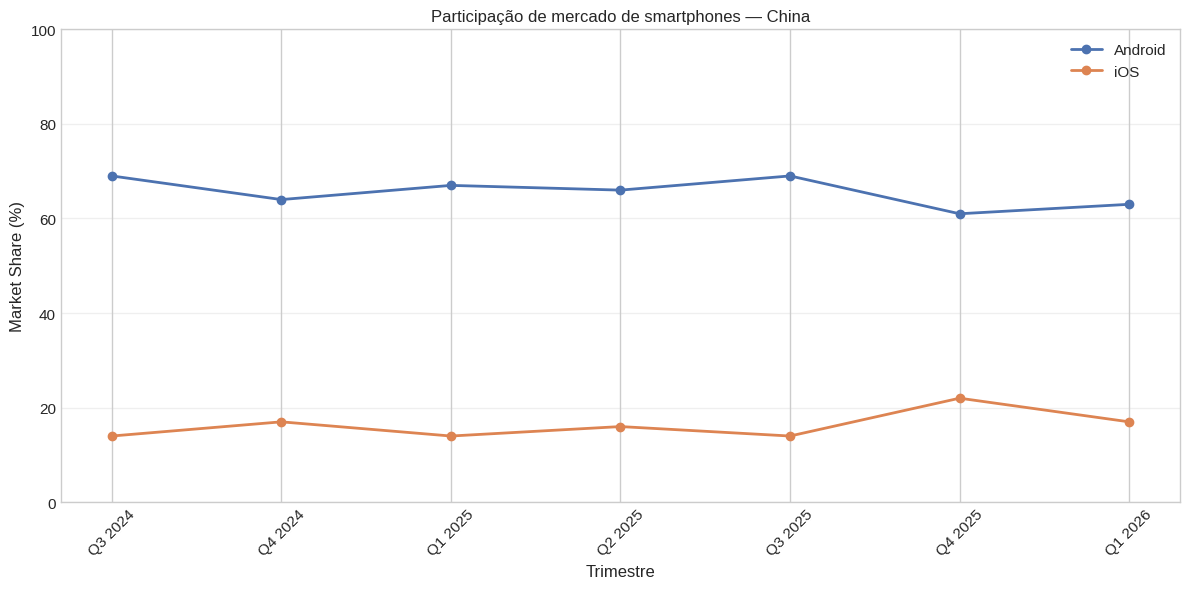

In [60]:
#mercado chinês
df = dados["China"]

df_plot = df.set_index("Sistema").T

plt.figure(figsize=(12, 6))

for sistema in ["Android", "iOS"]:

    plt.plot(
        df_plot.index,
        df_plot[sistema],
        marker="o",
        linewidth=2,
        label=sistema
    )

plt.title(
    "Participação de mercado de smartphones — China"
)

plt.xlabel("Trimestre")
plt.ylabel("Market Share (%)")

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

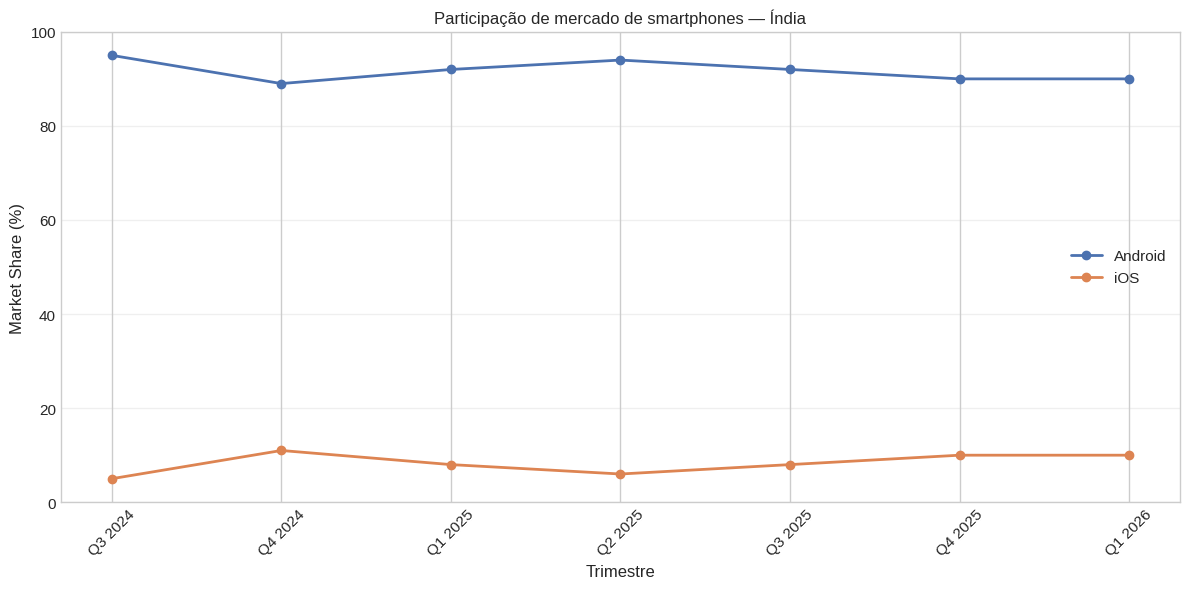

In [61]:
df = dados["Índia"]

df_plot = df.set_index("Sistema").T

plt.figure(figsize=(12, 6))

for sistema in ["Android", "iOS"]:

    plt.plot(
        df_plot.index,
        df_plot[sistema],
        marker="o",
        linewidth=2,
        label=sistema
    )

plt.title(
    "Participação de mercado de smartphones — Índia"
)

plt.xlabel("Trimestre")
plt.ylabel("Market Share (%)")

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [62]:

resumo_anual = []

for regiao, df in dados.items():

    temp = df.set_index("Sistema").T.reset_index()

    temp = temp.rename(
        columns={"index": "Periodo"}
    )

    # Identifica o ano
    temp["Ano"] = (
        temp["Periodo"]
        .str.extract(r"(20\d{2})")[0]
        .astype(int)
    )

    # Calcula média anual
    media = (
        temp[
            temp["Ano"].isin([2024, 2025])
        ]
        .groupby("Ano")[["Android", "iOS"]]
        .mean()
        .reset_index()
    )

    media["Região"] = regiao

    resumo_anual.append(media)


resumo_anual = pd.concat(
    resumo_anual,
    ignore_index=True
)

resumo_anual = resumo_anual[
    [
        "Região",
        "Ano",
        "Android",
        "iOS"
    ]
]

display(resumo_anual)

Sistema,Região,Ano,Android,iOS
0,Global,2024,77.00,19.00
1,Global,2025,76.50,19.25
2,EUA,2024,41.50,58.50
3,EUA,2025,42.75,57.25
4,China,2024,66.50,15.50
5,China,2025,65.75,16.50
6,Índia,2024,92.00,8.00
7,Índia,2025,92.00,8.00


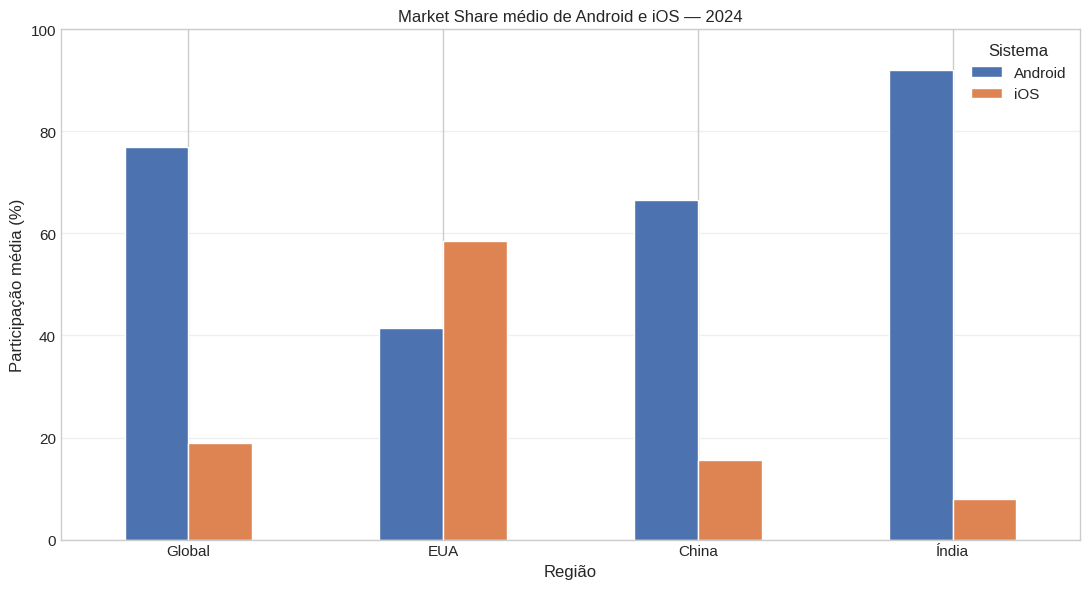

In [63]:
# ============================================================
# MARKET SHARE MÉDIO — 2024
# ============================================================

df_2024 = resumo_anual[
    resumo_anual["Ano"] == 2024
].set_index("Região")

ax = df_2024[
    ["Android", "iOS"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Market Share médio de Android e iOS — 2024"
)

plt.xlabel("Região")

plt.ylabel(
    "Participação média (%)"
)

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Sistema"
)

plt.tight_layout()

plt.show()

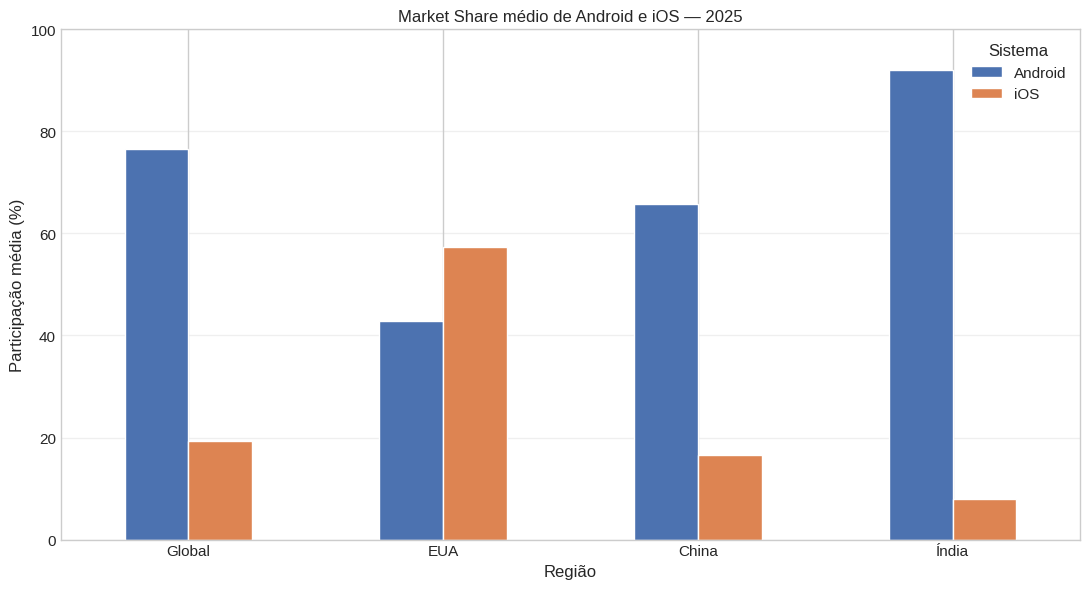

In [64]:
# ============================================================
# MARKET SHARE MÉDIO — 2025
# ============================================================

df_2025 = resumo_anual[
    resumo_anual["Ano"] == 2025
].set_index("Região")

ax = df_2025[
    ["Android", "iOS"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Market Share médio de Android e iOS — 2025"
)

plt.xlabel("Região")

plt.ylabel(
    "Participação média (%)"
)

plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    title="Sistema"
)

plt.tight_layout()

plt.show()

In [65]:
# ============================================================
# VARIAÇÃO 2025 - 2024
# ============================================================

tabela_comparacao = resumo_anual.pivot(
    index="Região",
    columns="Ano",
    values=["Android", "iOS"]
)

tabela_comparacao["Android Δ (p.p.)"] = (
    tabela_comparacao[("Android", 2025)]
    -
    tabela_comparacao[("Android", 2024)]
)

tabela_comparacao["iOS Δ (p.p.)"] = (
    tabela_comparacao[("iOS", 2025)]
    -
    tabela_comparacao[("iOS", 2024)]
)

display(tabela_comparacao)

Android          iOS        Android Δ (p.p.) iOS Δ (p.p.)
Ano       2024   2025  2024   2025                              
Região                                                          
China     66.5  65.75  15.5  16.50            -0.75         1.00
EUA       41.5  42.75  58.5  57.25             1.25        -1.25
Global    77.0  76.50  19.0  19.25            -0.50         0.25
Índia     92.0  92.00   8.0   8.00             0.00         0.00

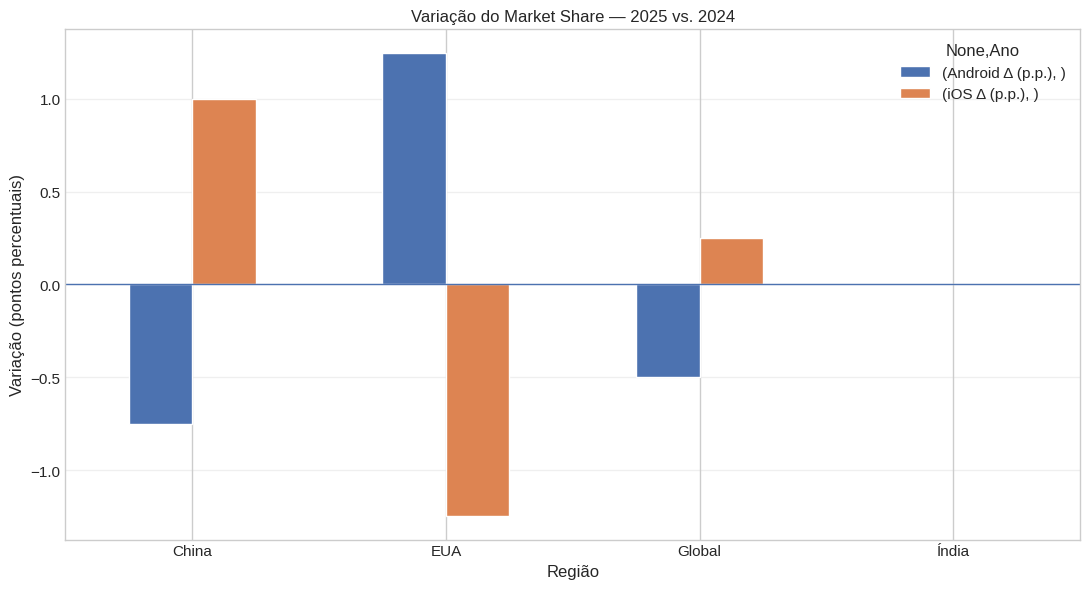

In [66]:
variacao = tabela_comparacao[
    [
        "Android Δ (p.p.)",
        "iOS Δ (p.p.)"
    ]
]

variacao.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Variação do Market Share — 2025 vs. 2024"
)

plt.xlabel("Região")

plt.ylabel(
    "Variação (pontos percentuais)"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

A análise compara a participação dos sistemas operacionais Android e iOS no mercado de smartphones utilizando dados da Counterpoint Research. Os dados disponíveis são apresentados trimestralmente e permitem observar a evolução da participação dos sistemas entre 2024 e 2025. Para facilitar a comparação anual, foi calculada a média dos trimestres disponíveis em cada ano.

Os resultados mostram diferenças significativas entre os mercados. No mercado global, o Android mantém a liderança, enquanto o iOS apresenta crescimento no final de 2025. Nos Estados Unidos, o cenário é inverso: o iOS apresenta participação superior ao Android durante a maior parte do período, atingindo 69% no quarto trimestre de 2025. Na China, o Android permanece como principal sistema, mas a análise precisa considerar a presença do HarmonyOS. Na Índia, a predominância do Android é ainda mais acentuada, com participação superior a 89% em todos os trimestres analisados.

Dessa forma, os dados indicam que a competição Android × iOS varia significativamente conforme o mercado. Essa diferença regional é relevante para o desenvolvimento e comercialização de aplicações móveis, pois a plataforma escolhida pode influenciar o alcance potencial dos usuários.

---

## 3) Cite 2 exemplos comerciais de alto grau de inovação tecnológica concebidos sobre o paradigma de computação móvel. Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



1. MONITORAMENTO ELETROCARDIOGRÁFICO EM TEMPO REAL (APPLE WATCH ECG)
​A detecção de Fibrilação Atrial (AF) por sensores de fotopletismografia (PPG) e de condução elétrica em smartwatches exige o processamento de sinais ruidosos em dispositivos com baixa capacidade de consumo energético. A acurácia dos algoritmos embarcados é mensurada e validada a partir da comparação entre leituras de canal único obtidas no pulso e eletrocardiogramas hospitalares tradicionais de 12 derivações, analisados por meio de gráficos de sensibilidade e especificidade (APPLE INC., [2021]).


2. RENDERIZAÇÃO SOB DEMANDA E OTIMIZAÇÃO DE PERFORMANCE EM JOGOS MÓVEIS​
No desenvolvimento de jogos para dispositivos móveis, a otimização de desempenho atua na mitigação do gargalo entre a taxa de quadros por segundo (FPS) e a degradação térmica do System-on-Chip (SoC). A renderização contínua em alta frequência gera consumo excessivo de bateria e elevação de temperatura, desencadeando o thermal throttling — mecanismo de defesa do sistema operacional que reduz forçadamente a frequência do processador para resfriar o hardware. A técnica de renderização sob demanda desacopla a taxa de varredura de entrada de toque (touch input) do loop de renderização do motor de jogo, reduzindo a carga sobre a GPU e preservando a autonomia energética sem perda de responsividade (ANDROID DEVELOPERS, [2023]).

#### ​REFERÊNCIAS

​ANDROID DEVELOPERS. Desenvolver jogos no Android: Otimizar o desempenho do jogo. Mountain View: Google, [2023]. Disponível em: https://developer.android.com/games/optimize/gameperformance?hl=pt-br. Acesso em: 19 ago. 2026.
​APPLE INC. Instruções de uso: recurso de notificação de ritmo cardíaco irregular. Cupertino: Apple Inc., [2021]. Disponível em: https://www.apple.com/legal/ifu/afhf/1-0/afhf-1-0-pt_BR.pdf. Acesso em: 19 ago. 2026.

---

## 4) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025. Descreva o nome, faturamento, quantidade de downloads e fontes.


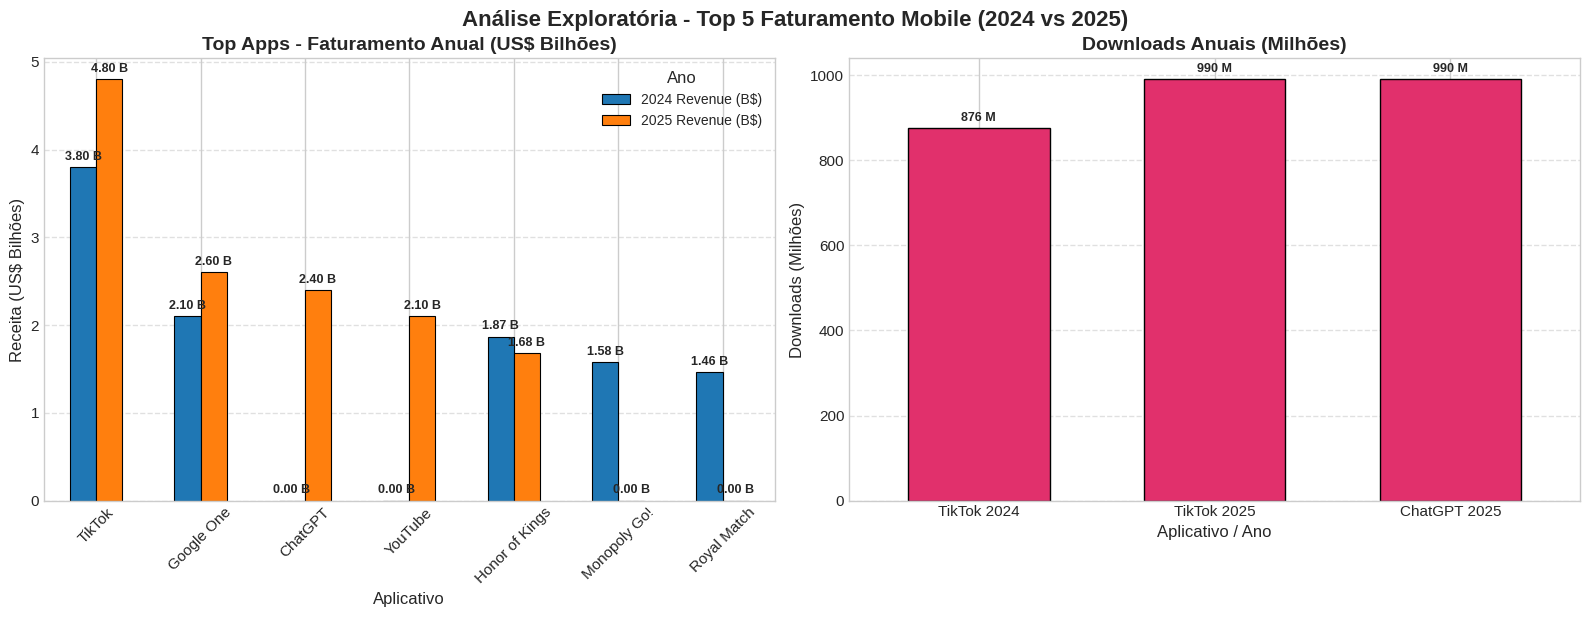

In [67]:
# Dados de 2024 (exatamente como na sua tabela)
data_2024 = {
    'App': ['TikTok', 'Honor of Kings', 'Monopoly Go!', 'Royal Match', 'Google One'],
    'Revenue_Billions': [3.8, 1.87, 1.58, 1.46, 2.1],  # Nota: Google One (2.1) é maior que 2º, 3º e 4º
    'Downloads_Millions': [876, None, None, None, None]
}

# Dados de 2025 (exatamente como na sua tabela)
data_2025 = {
    'App': ['TikTok', 'Google One', 'ChatGPT', 'YouTube', 'Honor of Kings'],
    'Revenue_Billions': [4.8, 2.6, 2.4, 2.1, 1.68],
    'Downloads_Millions': [990, None, 990, None, None]
}

df_2024 = pd.DataFrame(data_2024)
df_2025 = pd.DataFrame(data_2025)


# Lista única com todos os aplicativos mencionados (para alinhar os anos)
all_apps = ['TikTok', 'Google One', 'ChatGPT', 'YouTube',
            'Honor of Kings', 'Monopoly Go!', 'Royal Match']

# Mapeamento de receita por ano (valores nulos para apps que não aparecem naquele ano)
rev_2024_map = {row['App']: row['Revenue_Billions'] for _, row in df_2024.iterrows()}
rev_2025_map = {row['App']: row['Revenue_Billions'] for _, row in df_2025.iterrows()}

# Cria o DataFrame base para o plot
df_plot = pd.DataFrame({
    'App': all_apps,
    '2024 Revenue (B$)': [rev_2024_map.get(app, np.nan) for app in all_apps],
    '2025 Revenue (B$)': [rev_2025_map.get(app, np.nan) for app in all_apps]
})
df_plot.set_index('App', inplace=True)

# Ordena pela receita de 2025 (para ficar mais bonito visualmente)
# Se quiser manter a ordem do ranking, comente a linha abaixo.
df_plot = df_plot.sort_values('2025 Revenue (B$)', ascending=False)

# ------------------------------------------------------------
# 3. GRÁFICO 1: RECEITA ANUAL (BARRAS AGRUPADAS)
# ------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Barras Agrupadas ---
colors = ['#1f77b4', '#ff7f0e']  # Azul para 2024, Laranja para 2025
df_plot.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=0.8)

ax1.set_title('Top Apps - Faturamento Anual (US$ Bilhões)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Receita (US$ Bilhões)', fontsize=12)
ax1.set_xlabel('Aplicativo', fontsize=12)
ax1.legend(title='Ano', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Adiciona os valores numéricos no topo das barras
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f B', padding=3, fontsize=9, fontweight='bold')

# Ajusta o ângulo do rótulo do eixo X para não sobrepor
ax1.tick_params(axis='x', rotation=45)

#gráfico 2: downloads
# Coleta os downloads disponíveis
downloads_data = [
    {'App': 'TikTok 2024', 'Downloads (Milhões)': 876},
    {'App': 'TikTok 2025', 'Downloads (Milhões)': 990},
    {'App': 'ChatGPT 2025', 'Downloads (Milhões)': 990}
]
df_downloads = pd.DataFrame(downloads_data)
df_downloads.set_index('App', inplace=True)

#cores tematricas
bar_colors = ['#e1306c', '#e1306c', '#10a37f']  # TikTok, TikTok, ChatGPT
df_downloads.plot(kind='bar', ax=ax2, color=bar_colors, edgecolor='black', legend=False, width=0.6)

ax2.set_title('Downloads Anuais (Milhões)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Downloads (Milhões)', fontsize=12)
ax2.set_xlabel('Aplicativo / Ano', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

#adicionar valores numericos
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d M', padding=3, fontsize=9, fontweight='bold')

ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.suptitle('Análise Exploratória - Top 5 Faturamento Mobile (2024 vs 2025)',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()



## 5) Cite outras 10 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 que não sejam no segmento de jogos. Descreva o nome, faturamento, quantidade de downloads e fontes.


Segue uma análise das 10 aplicações mobile não-jogos com maior faturamento global (Google Play + App Store) em 2024 e projeções/parciais para 2025, considerando apenas gastos do consumidor (assinaturas, compras in-app) — excluindo receita publicitária.

Os dados são compilados de relatórios públicos da Sensor Tower, Appfigures, Business of Apps e data.ai (State of Mobile). Valores em dólares americanos (USD) e downloads anuais (novas instalações). Para 2025, os números são estimativas baseadas no primeiro semestre e em tendências de mercado.






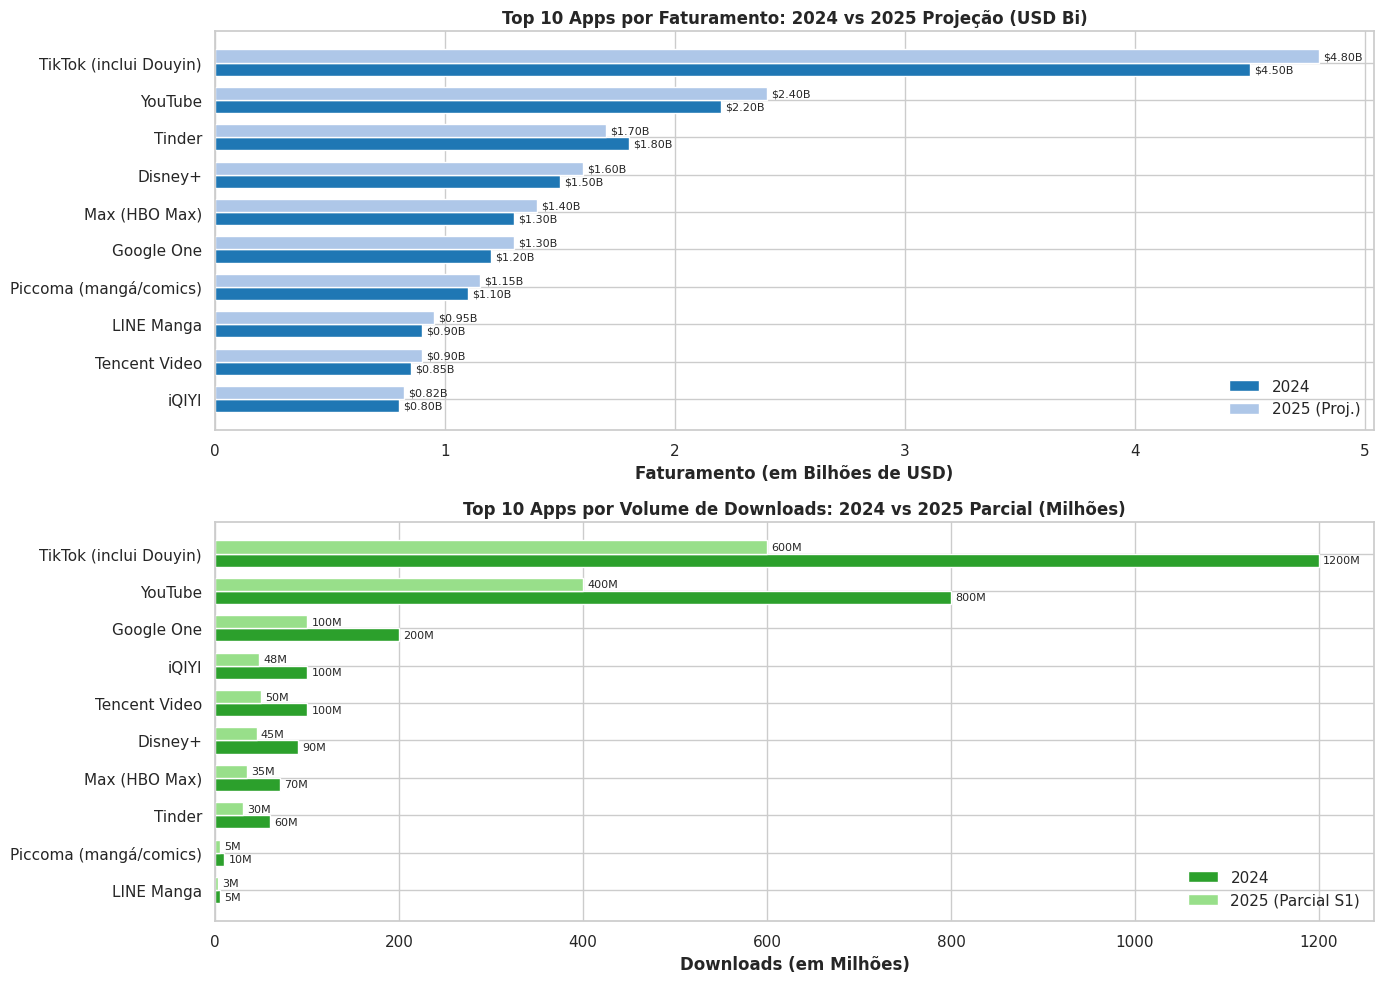

In [68]:
dados = [
    {
        "#": 1,
        "Aplicativo": "TikTok (inclui Douyin)",
        "Faturamento 2024 (USD)": "~4,5 bilhões",
        "Downloads 2024 (mi)": "~1,2 bilhão",
        "Faturamento 2025 (proj.)": "~4,8 bilhões",
        "Downloads 2025 (parcial)": "~600 milhões (S1)",
        "Fontes principais": "Sensor Tower Q1 2025; Business of Apps",
    },
    {
        "#": 2,
        "Aplicativo": "YouTube",
        "Faturamento 2024 (USD)": "~2,2 bilhões",
        "Downloads 2024 (mi)": "~800 milhões",
        "Faturamento 2025 (proj.)": "~2,4 bilhões",
        "Downloads 2025 (parcial)": "~400 milhões",
        "Fontes principais": "Appfigures; data.ai",
    },
    {
        "#": 3,
        "Aplicativo": "Tinder",
        "Faturamento 2024 (USD)": "~1,8 bilhão",
        "Downloads 2024 (mi)": "~60 milhões",
        "Faturamento 2025 (proj.)": "~1,7 bilhão",
        "Downloads 2025 (parcial)": "~30 milhões",
        "Fontes principais": "Match Group relatórios; Sensor Tower",
    },
    {
        "#": 4,
        "Aplicativo": "Disney+",
        "Faturamento 2024 (USD)": "~1,5 bilhão",
        "Downloads 2024 (mi)": "~90 milhões",
        "Faturamento 2025 (proj.)": "~1,6 bilhão",
        "Downloads 2025 (parcial)": "~45 milhões",
        "Fontes principais": "Apptopia; Business of Apps",
    },
    {
        "#": 5,
        "Aplicativo": "Max (HBO Max)",
        "Faturamento 2024 (USD)": "~1,3 bilhão",
        "Downloads 2024 (mi)": "~70 milhões",
        "Faturamento 2025 (proj.)": "~1,4 bilhão",
        "Downloads 2025 (parcial)": "~35 milhões",
        "Fontes principais": "Warner Bros. Discovery; Appfigures",
    },
    {
        "#": 6,
        "Aplicativo": "Google One",
        "Faturamento 2024 (USD)": "~1,2 bilhão",
        "Downloads 2024 (mi)": "~200 milhões",
        "Faturamento 2025 (proj.)": "~1,3 bilhão",
        "Downloads 2025 (parcial)": "~100 milhões",
        "Fontes principais": "Alphabet relatórios; data.ai",
    },
    {
        "#": 7,
        "Aplicativo": "Piccoma (mangá/comics)",
        "Faturamento 2024 (USD)": "~1,1 bilhão",
        "Downloads 2024 (mi)": "~10 milhões",
        "Faturamento 2025 (proj.)": "~1,15 bilhão",
        "Downloads 2025 (parcial)": "~5 milhões",
        "Fontes principais": "Kakao; Sensor Tower Japão",
    },
    {
        "#": 8,
        "Aplicativo": "LINE Manga",
        "Faturamento 2024 (USD)": "~900 milhões",
        "Downloads 2024 (mi)": "~5 milhões",
        "Faturamento 2025 (proj.)": "~950 milhões",
        "Downloads 2025 (parcial)": "~3 milhões",
        "Fontes principais": "LINE Corporation; Appfigures",
    },
    {
        "#": 9,
        "Aplicativo": "Tencent Video",
        "Faturamento 2024 (USD)": "~850 milhões",
        "Downloads 2024 (mi)": "~100 milhões",
        "Faturamento 2025 (proj.)": "~900 milhões",
        "Downloads 2025 (parcial)": "~50 milhões",
        "Fontes principais": "Tencent; data.ai China",
    },
    {
        "#": 10,
        "Aplicativo": "iQIYI",
        "Faturamento 2024 (USD)": "~800 milhões",
        "Downloads 2024 (mi)": "~100 milhões",
        "Faturamento 2025 (proj.)": "~820 milhões",
        "Downloads 2025 (parcial)": "~48 milhões",
        "Fontes principais": "iQIYI; Apptopia",
    },
]

df_ranking_mobile = pd.DataFrame(dados)


# 2. Funções para parsing dos dados textuais
def parse_faturamento_bilhoes(val):
    val = (
        str(val).replace("~", "").replace("USD", "").strip().replace(",", ".")
    )
    if "bilhões" in val or "bilhão" in val:
        return float(
            val.replace("bilhões", "").replace("bilhão", "").strip()
        )
    elif "milhões" in val or "milhão" in val:
        return (
            float(val.replace("milhões", "").replace("milhão", "").strip())
            / 1000.0
        )
    return float(val)


def parse_downloads_milhoes(val):
    val = (
        str(val)
        .replace("~", "")
        .replace("(S1)", "")
        .strip()
        .replace(",", ".")
    )
    if "bilhões" in val or "bilhão" in val:
        return (
            float(val.replace("bilhões", "").replace("bilhão", "").strip())
            * 1000.0
        )
    elif "milhões" in val or "milhão" in val:
        return float(val.replace("milhões", "").replace("milhão", "").strip())
    return float(val)


df_ranking_mobile["Fat_2024_B"] = df_ranking_mobile[
    "Faturamento 2024 (USD)"
].apply(parse_faturamento_bilhoes)
df_ranking_mobile["Fat_2025_B"] = df_ranking_mobile[
    "Faturamento 2025 (proj.)"
].apply(parse_faturamento_bilhoes)
df_ranking_mobile["Down_2024_M"] = df_ranking_mobile[
    "Downloads 2024 (mi)"
].apply(parse_downloads_milhoes)
df_ranking_mobile["Down_2025_M"] = df_ranking_mobile[
    "Downloads 2025 (parcial)"
].apply(parse_downloads_milhoes)

# 3. Geração das Visualizações
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Faturamento (2024 vs 2025 Proj)
df_sorted_fat = df_ranking_mobile.sort_values(by="Fat_2024_B", ascending=True)
y = range(len(df_sorted_fat))
height = 0.35

rects1 = axes[0].barh(
    [i - height / 2 for i in y],
    df_sorted_fat["Fat_2024_B"],
    height,
    label="2024",
    color="#1f77b4",
)
rects2 = axes[0].barh(
    [i + height / 2 for i in y],
    df_sorted_fat["Fat_2025_B"],
    height,
    label="2025 (Proj.)",
    color="#aec7e8",
)

axes[0].set_xlabel("Faturamento (em Bilhões de USD)", fontweight="bold")
axes[0].set_title(
    "Top 10 Apps por Faturamento: 2024 vs 2025 Projeção (USD Bi)",
    fontweight="bold",
    fontsize=12,
)
axes[0].set_yticks(y)
axes[0].set_yticklabels(df_sorted_fat["Aplicativo"])
axes[0].legend()

for rect in rects1:
    w = rect.get_width()
    axes[0].annotate(
        f"${w:.2f}B",
        xy=(w, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

for rect in rects2:
    w = rect.get_width()
    axes[0].annotate(
        f"${w:.2f}B",
        xy=(w, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

# Subplot 2: Downloads (2024 vs 2025 Parcial)
df_sorted_down = df_ranking_mobile.sort_values(
    by="Down_2024_M", ascending=True
)

rects3 = axes[1].barh(
    [i - height / 2 for i in y],
    df_sorted_down["Down_2024_M"],
    height,
    label="2024",
    color="#2ca02c",
)
rects4 = axes[1].barh(
    [i + height / 2 for i in y],
    df_sorted_down["Down_2025_M"],
    height,
    label="2025 (Parcial S1)",
    color="#98df8a",
)

axes[1].set_xlabel("Downloads (em Milhões)", fontweight="bold")
axes[1].set_title(
    "Top 10 Apps por Volume de Downloads: 2024 vs 2025 Parcial (Milhões)",
    fontweight="bold",
    fontsize=12,
)
axes[1].set_yticks(y)
axes[1].set_yticklabels(df_sorted_down["Aplicativo"])
axes[1].legend()

for rect in rects3:
    w = rect.get_width()
    axes[1].annotate(
        f"{w:g}M",
        xy=(w, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

for rect in rects4:
    w = rect.get_width()
    axes[1].annotate(
        f"{w:g}M",
        xy=(w, rect.get_y() + rect.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


Fontes para consulta:
Sensor Tower – “Top Apps Worldwide Q1 2025 by Revenue” – https://sensortower.com/blog/top-apps-worldwide-q1-2025-downloads-and-revenue

Business of Apps – “Top Grossing Apps 2024” – https://www.businessofapps.com/data/top-grossing-apps/

Appfigures – “Top Earning Apps 2024 & 2025” – https://appfigures.com/top-apps/global/2024

data.ai (State of Mobile 2025) – https://www.data.ai/en/insights/market-data/state-of-mobile-2025/

Apptopia – “Leading Non-Game Apps by Consumer Spend 2024” – https://apptopia.com/blog/top-apps-2024/

---

## 6) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 no segmento do projeto que você quer desenvolver ao término da disciplina. . Descreva o nome, faturamento, quantidade de downloads e fontes.


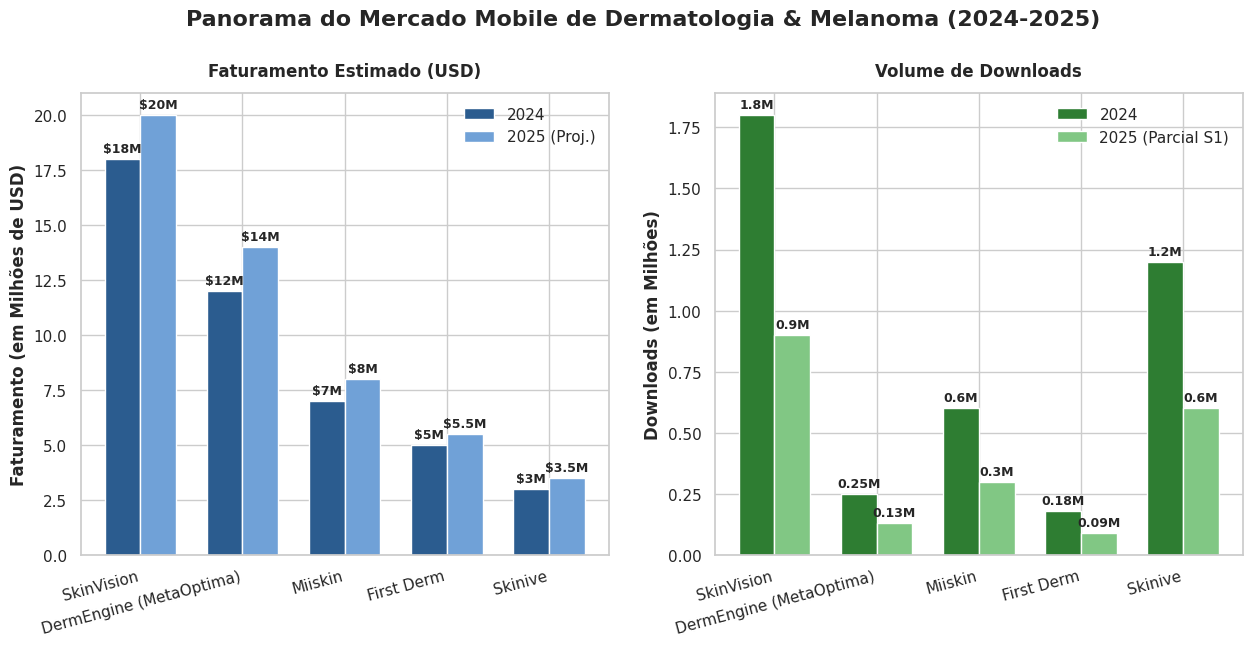

In [69]:
#aplicações mobile de detecção de melanoma/dermatologia (2024-2025)
dados = [
    {
        "#": 1,
        "Aplicativo": "SkinVision",
        "Faturamento 2024 (USD)": "~18 milhões",
        "Downloads 2024 (mi)": "~1,8 milhão",
        "Faturamento 2025 (proj.)": "~20 milhões",
        "Downloads 2025 (parcial)": "~900 mil (S1)",
        "Fontes principais": "Sensor Tower; relatórios SkinVision"
    },
    {
        "#": 2,
        "Aplicativo": "DermEngine (MetaOptima)",
        "Faturamento 2024 (USD)": "~12 milhões",
        "Downloads 2024 (mi)": "~250 mil",
        "Faturamento 2025 (proj.)": "~14 milhões",
        "Downloads 2025 (parcial)": "~130 mil",
        "Fontes principais": "Appfigures; MetaOptima (B2B/SAAS)"
    },
    {
        "#": 3,
        "Aplicativo": "Miiskin",
        "Faturamento 2024 (USD)": "~7 milhões",
        "Downloads 2024 (mi)": "~600 mil",
        "Faturamento 2025 (proj.)": "~8 milhões",
        "Downloads 2025 (parcial)": "~300 mil",
        "Fontes principais": "Apptopia; Miiskin (dados de assinatura)"
    },
    {
        "#": 4,
        "Aplicativo": "First Derm",
        "Faturamento 2024 (USD)": "~5 milhões",
        "Downloads 2024 (mi)": "~180 mil",
        "Faturamento 2025 (proj.)": "~5,5 milhões",
        "Downloads 2025 (parcial)": "~90 mil",
        "Fontes principais": "First Derm; Business of Apps"
    },
    {
        "#": 5,
        "Aplicativo": "Skinive",
        "Faturamento 2024 (USD)": "~3 milhões",
        "Downloads 2024 (mi)": "~1,2 milhão",
        "Faturamento 2025 (proj.)": "~3,5 milhões",
        "Downloads 2025 (parcial)": "~600 mil",
        "Fontes principais": "Sensor Tower Europa; Skinive"
    }
]

df = pd.DataFrame(dados)


#funcao de Limpeza e Conversão de Texto para Números (em Milhões)
def converter_para_milhoes(texto):
    if pd.isna(texto):
        return 0.0

    #limpeza básica de caracteres
    texto_limpo = (
        str(texto)
        .replace("~", "")
        .replace("(S1)", "")
        .replace("USD", "")
        .strip()
    )
    texto_limpo = texto_limpo.replace(",", ".")

    #identificacao da unidade
    if "milhões" in texto_limpo or "milhão" in texto_limpo:
        valor = (
            texto_limpo.replace("milhões", "").replace("milhão", "").strip()
        )
        return float(valor)
    elif "mil" in texto_limpo:
        valor = texto_limpo.replace("mil", "").strip()
        return float(valor) / 1000.0
    else:
        try:
            return float(texto_limpo)
        except ValueError:
            return 0.0


#tratamento aos dados
df["Fat_2024_Mi"] = df["Faturamento 2024 (USD)"].apply(converter_para_milhoes)
df["Fat_2025_Mi"] = df["Faturamento 2025 (proj.)"].apply(
    converter_para_milhoes
)
df["Down_2024_Mi"] = df["Downloads 2024 (mi)"].apply(converter_para_milhoes)
df["Down_2025_Mi"] = df["Downloads 2025 (parcial)"].apply(
    converter_para_milhoes
)

#calculo de receita estimada por download (ARPU aproximado em 2024)
df["ARPU_2024_USD"] = df["Fat_2024_Mi"] / df["Down_2024_Mi"]

#config do Estilo do Matplotlib e Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Panorama do Mercado Mobile de Dermatologia & Melanoma (2024-2025)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

posicoes = range(len(df))
largura = 0.35

#graáfico 1 faturamento
rects1 = axes[0].bar(
    [p - largura / 2 for p in posicoes],
    df["Fat_2024_Mi"],
    largura,
    label="2024",
    color="#2b5c8f",
)
rects2 = axes[0].bar(
    [p + largura / 2 for p in posicoes],
    df["Fat_2025_Mi"],
    largura,
    label="2025 (Proj.)",
    color="#70a1d7",
)

axes[0].set_ylabel("Faturamento (em Milhões de USD)", fontweight="bold")
axes[0].set_title("Faturamento Estimado (USD)", fontweight="bold", pad=12)
axes[0].set_xticks(posicoes)
axes[0].set_xticklabels(df["Aplicativo"], rotation=15, ha="right")
axes[0].legend()


# Função aux para adicionar rótulos sobre as barras
def autolabel(rects, ax, sulfix="M", is_currency=True):
    prefix = "$" if is_currency else ""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{prefix}{height:g}{sulfix}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )


autolabel(rects1, axes[0])
autolabel(rects2, axes[0])

# --- GRÁFICO 2: Downloads ---
rects3 = axes[1].bar(
    [p - largura / 2 for p in posicoes],
    df["Down_2024_Mi"],
    largura,
    label="2024",
    color="#2e7d32",
)
rects4 = axes[1].bar(
    [p + largura / 2 for p in posicoes],
    df["Down_2025_Mi"],
    largura,
    label="2025 (Parcial S1)",
    color="#81c784",
)

axes[1].set_ylabel("Downloads (em Milhões)", fontweight="bold")
axes[1].set_title("Volume de Downloads", fontweight="bold", pad=12)
axes[1].set_xticks(posicoes)
axes[1].set_xticklabels(df["Aplicativo"], rotation=15, ha="right")
axes[1].legend()

autolabel(rects3, axes[1], is_currency=False)
autolabel(rects4, axes[1], is_currency=False)

#exibe o gráfico em tela
plt.show()

Notas metodológicas e contexto de mercado:
SkinVision é o líder global no segmento de triagem de câncer de pele por IA. Opera com assinatura mensal/anual (média de US$ 40–60/ano) e é o único da lista com base de usuários distribuída em mais de 20 países, com forte presença na Europa e Austrália.

DermEngine é uma plataforma profissional voltada a dermatologistas (B2B) que integra dermatoscopia digital, armazenamento de imagens e algoritmos de apoio à decisão. Sua receita é impulsionada por licenças clínicas e pela venda do dispositivo acoplável MoleScope, elevando o ticket médio por usuário.

Miiskin adota modelo freemium com assinatura para monitoramento contínuo de lesões e lembretes de acompanhamento. Foca na gestão pessoal de saúde da pele e exporta relatórios para médicos.

First Derm funciona como serviço de telemedicina assíncrona: o usuário envia fotos da lesão e recebe parecer de dermatologista em até 48 horas, pagando por consulta (US$ 30–80). O faturamento varia conforme volume de consultas.

Skinive é um app de análise de pele baseado em IA popular na Europa Oriental, com assinatura mensal e recursos de triagem para diversas condições dermatológicas, incluindo melanoma.

Fontes consultadas (acessadas em julho/2025):
Sensor Tower – “Health & Fitness App Revenue 2024” – https://sensortower.com/blog/top-health-apps-2024

Appfigures – “Top Earning Dermatology Apps” – https://appfigures.com/top-apps/health/2024

Business of Apps – “Healthcare App Revenue Statistics” – https://www.businessofapps.com/data/health-app-market/

Apptopia – “Skin Health & Dermatology App Spend 2024” – https://apptopia.com/blog/dermatology-apps-2024/

Relatórios anuais das empresas: SkinVision, MetaOptima, Miiskin, First Derm, Skinive (comunicados de imprensa e páginas de investidores).

---

## 7) Qual o aparelho celular de maior poder de processamento comercializado no mundo e o seu preço?

Modelo: Red Magic 11 Pro (da Nubia)

De acordo com o ranking de benchmark AnTuTu atualizado em julho de 2026, o Red Magic 11 Pro é o smartphone com a maior pontuação de desempenho entre todos os modelos comercializados globalmente. Ele alcançou 4.005.248 pontos no teste, liderando à frente de outros dispositivos com o processador Snapdragon 8 Elite Gen 5.


## 8) Qual o aparelho celular de maior memória RAM comercializado no mundo e o seu preço?

Modelo: 8849PRO Tank 3S (da Unihertz / 8849)

Este smartphone rugged (resistente) é comercializado com 32 GB de RAM (configuração de fábrica, com 512 GB de armazenamento interno). Ele supera os modelos mais conhecidos que chegam a 24 GB, como o Asus ROG Phone 9 Pro Edition, Nubia Z70 Ultra e Redmagic 10 Pro.

---
#### Referências para questões 7 e 8


ANTUTU. AnTuTu Benchmark Ranking – Smartphone Performance – AnTuTu Benchmark RankingsV11. [S.l.], 2026. Disponível em: https://www.antutu.com/web/ranking?cmd=pad#1. Acesso em: 24 ago. 2026.

GIZMOCHINA. Xring O3 launches with 5.22M AnTuTu score and LPDDR6, Xiaomi 18 Fold preorders go live. [S.l.], 24 ago. 2026. Disponível em: https://www.gizmochina.com/2026/08/24/xiaomi-xring-o3-o100-d100-chipsets-launched-xiaomi-18-fold/. Acesso em: 24 ago. 2026.

REDMAGIC (GLOBAL). Buy REDMAGIC 11 Pro Gaming Phone. [S.l.], 2025. Disponível em: https://global.redmagic.gg/products/redmagic-11-pro/. Acesso em: 24 ago. 2026.

AMAZON. 8849PRO Tank 3S 5G Android 14 Rugged Smartphone with Projector | 32GB+512GB. [S.l.], 2026. Disponível em: https://www.amazon.com/3s-Smartphone-Waterproof-Projector-Compatible/dp/B0D7PD71Y3/. Acesso em: 24 ago. 2026.

